In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Concatenate, BatchNormalization, Activation, Add
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.datasets import mnist, cifar10
from google.colab import files
from sklearn.metrics import mean_squared_error
import time
import os

%matplotlib inline

print("✅ Libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")

✅ Libraries imported successfully!
TensorFlow version: 2.20.0


Saving Cameraman.png to Cameraman.png
✅ Image loaded. Shape: (256, 256)
   Min pixel value: 0.027
   Max pixel value: 0.992


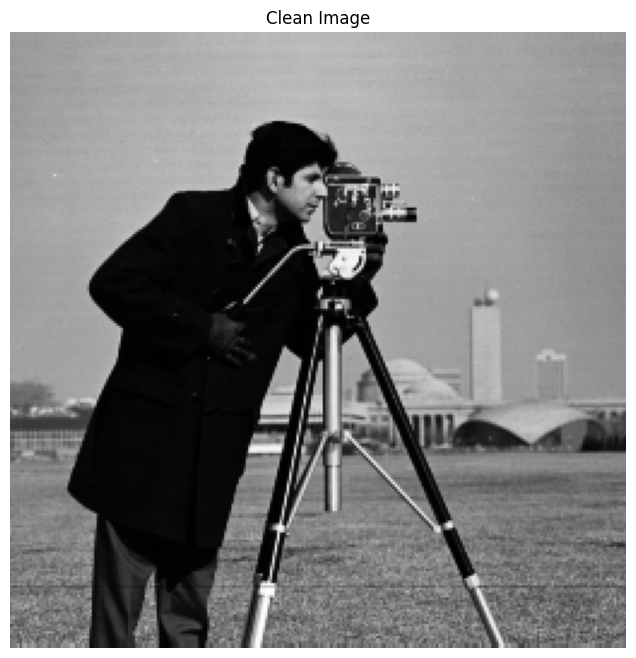

In [3]:
# Upload an image
uploaded = files.upload()
image_name = list(uploaded.keys())[0]

# Load and convert to grayscale (for simplicity in this opening)
image = cv2.imread(image_name)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Normalize to [0, 1] range
image_clean = image_gray.astype('float32') / 255.0

# Resize for faster processing (optional)
image_clean = cv2.resize(image_clean, (256, 256))

print(f"✅ Image loaded. Shape: {image_clean.shape}")
print(f"   Min pixel value: {image_clean.min():.3f}")
print(f"   Max pixel value: {image_clean.max():.3f}")

# Display the clean image
plt.figure(figsize=(8, 8))
plt.imshow(image_clean, cmap='gray')
plt.title('Clean Image')
plt.axis('off')
plt.show()

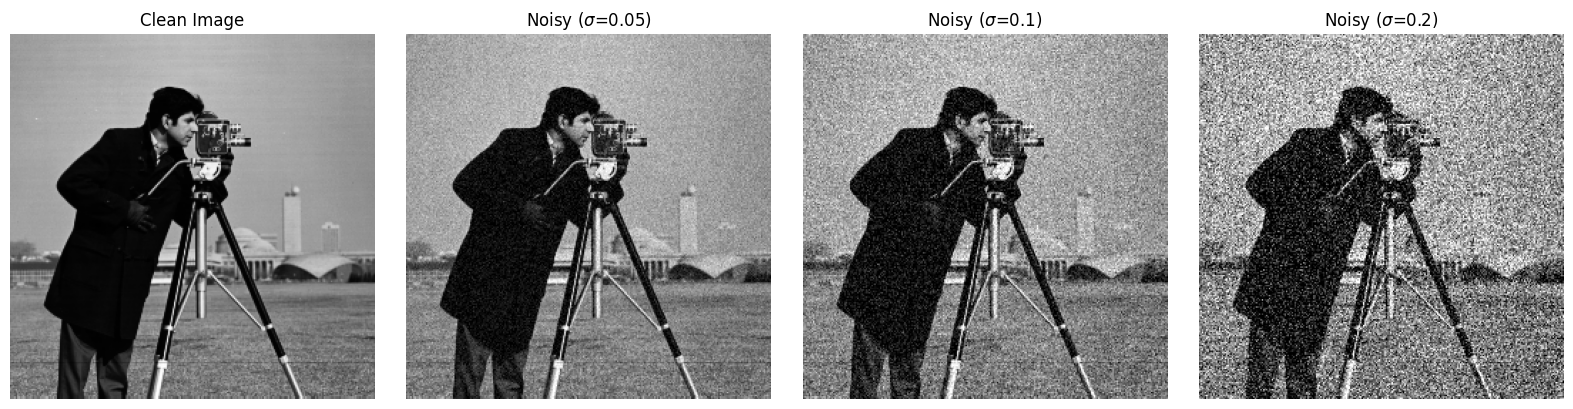

✅ Using noise with σ=0.1 for the remainder of this section


In [4]:
def add_gaussian_noise(image, sigma=0.1):
    """Add Gaussian noise to an image."""
    noise = np.random.normal(0, sigma, image.shape)
    noisy = image + noise
    return np.clip(noisy, 0, 1)

# Add noise with different intensities
sigma_values = [0.05, 0.1, 0.2]
noisy_images = {}

for sigma in sigma_values:
    noisy_images[sigma] = add_gaussian_noise(image_clean, sigma)

# Display the results
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(image_clean, cmap='gray')
axes[0].set_title('Clean Image')
axes[0].axis('off')

for i, sigma in enumerate(sigma_values):
    axes[i+1].imshow(noisy_images[sigma], cmap='gray')
    axes[i+1].set_title(f'Noisy ($\\sigma$={sigma})')
    axes[i+1].axis('off')

plt.tight_layout()
plt.show()

# Use sigma=0.1 for the rest of the hands-on opening
image_noisy = noisy_images[0.1]
print(f"✅ Using noise with σ=0.1 for the remainder of this section")

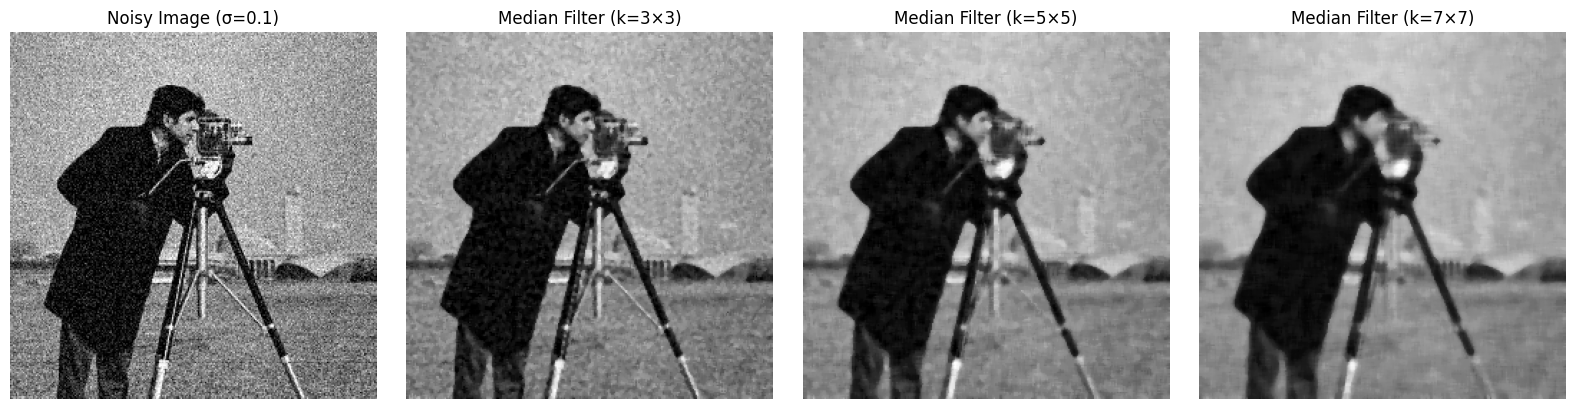

PSNR (Median filter, k=3): 24.30 dB


In [5]:
# Apply median filter with different kernel sizes
kernel_sizes = [3, 5, 7]
denoised_median = {}

for k in kernel_sizes:
    denoised_median[k] = cv2.medianBlur((image_noisy * 255).astype(np.uint8), k) / 255.0

# Display the results
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(image_noisy, cmap='gray')
axes[0].set_title('Noisy Image (σ=0.1)')
axes[0].axis('off')

for i, k in enumerate(kernel_sizes):
    axes[i+1].imshow(denoised_median[k], cmap='gray')
    axes[i+1].set_title(f'Median Filter (k={k}×{k})')
    axes[i+1].axis('off')

plt.tight_layout()
plt.show()

# Compute PSNR for the best median filter result (k=3)
from skimage.metrics import peak_signal_noise_ratio
psnr_median = peak_signal_noise_ratio(image_clean, denoised_median[3], data_range=1.0)
print(f"PSNR (Median filter, k=3): {psnr_median:.2f} dB")

In [6]:
# ============================================
#   Download BSDS500 from GitHub Mirror
# ============================================

import os
import subprocess
import shutil

DATASET_REPO = "https://github.com/BIDS/BSDS500.git"
CLONE_DIR = "BSDS500_repo"

def download_bsds500():
    """Clone the BSDS500 dataset from GitHub (already extracted)."""
    # If the clone directory exists and appears complete, skip cloning
    if os.path.exists(CLONE_DIR):
        expected_path = os.path.join(CLONE_DIR, "BSDS500", "data", "images")
        if os.path.exists(expected_path):
            print(f"✅ Dataset already cloned in '{CLONE_DIR}'")
            return True
        else:
            print(f"⚠️ Directory '{CLONE_DIR}' exists but seems incomplete. Removing...")
            shutil.rmtree(CLONE_DIR)

    print("🔄 Cloning BSDS500 from GitHub mirror...")
    try:
        # Run git clone with depth 1 to get only the latest version
        subprocess.run(['git', 'clone', '--depth', '1', DATASET_REPO, CLONE_DIR], check=True)
        print(f"✅ Clone successful. Data is in '{CLONE_DIR}/BSDS500/data/images'")
        return True
    except subprocess.CalledProcessError as e:
        print(f"❌ Clone failed with error: {e}")
        return False
    except Exception as e:
        print(f"❌ Unexpected error: {e}")
        return False

# Execute download and set paths
if download_bsds500():
    BASE_DIR = os.path.join(CLONE_DIR, "BSDS500", "data", "images")
    TRAIN_DIR = os.path.join(BASE_DIR, "train")
    VAL_DIR   = os.path.join(BASE_DIR, "val")
    TEST_DIR  = os.path.join(BASE_DIR, "test")
    print(f"✅ Paths set:\n  Train: {TRAIN_DIR}\n  Val:   {VAL_DIR}\n  Test:  {TEST_DIR}")
else:
    print("❌ Could not obtain dataset. Please check your internet connection or manually download.")

🔄 Cloning BSDS500 from GitHub mirror...
✅ Clone successful. Data is in 'BSDS500_repo/BSDS500/data/images'
✅ Paths set:
  Train: BSDS500_repo/BSDS500/data/images/train
  Val:   BSDS500_repo/BSDS500/data/images/val
  Test:  BSDS500_repo/BSDS500/data/images/test


In [7]:
PATCH_SIZE = 64
STRIDE = 64

def load_image(path, grayscale=True):
    """Load image as float32 in [0,1]."""
    if grayscale:
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE).astype(np.float32) / 255.0
    else:
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    return img

def get_image_paths(directory):
    """Return list of all .jpg/.png paths in a directory."""
    if not os.path.exists(directory):
        return []
    return [os.path.join(directory, f) for f in os.listdir(directory)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

def extract_patches_from_image(image):
    """Extract non‑overlapping patches (grayscale)."""
    h, w = image.shape
    patches = []
    for y in range(0, h - PATCH_SIZE + 1, STRIDE):
        for x in range(0, w - PATCH_SIZE + 1, STRIDE):
            patch = image[y:y+PATCH_SIZE, x:x+PATCH_SIZE]
            patches.append(patch)
    return np.array(patches, dtype=np.float32)

def extract_patches_from_directory(directory, max_images=None, verbose=True):
    """Extract patches from all images in a folder."""
    paths = get_image_paths(directory)
    if max_images:
        paths = paths[:max_images]
    all_patches = []
    for i, p in enumerate(paths):
        if verbose and i % 50 == 0:
            print(f"  Processing {i+1}/{len(paths)} ...")
        img = load_image(p, grayscale=True)
        patches = extract_patches_from_image(img)
        all_patches.extend(patches)
    return np.array(all_patches, dtype=np.float32)

In [8]:
def build_cnn_denoiser(input_shape=(PATCH_SIZE, PATCH_SIZE, 1)):
    inputs = Input(shape=input_shape)
    x = Conv2D(64, (3,3), activation='relu', padding='same')(inputs)
    x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
    outputs = Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(1e-3), loss='mse')
    return model

cnn_denoiser = build_cnn_denoiser()
cnn_denoiser.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 1)      │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 112,001 (437.50 KB)

 Trainable params: 112,001 (437.50 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
print("Extracting training patches (this may take a few minutes)...")
train_patches = extract_patches_from_directory(TRAIN_DIR, max_images=None)  # all 200 images
print(f"Training patches: {train_patches.shape[0]}")

print("Extracting validation patches...")
val_patches = extract_patches_from_directory(VAL_DIR, max_images=None)
print(f"Validation patches: {val_patches.shape[0]}")

Extracting training patches (this may take a few minutes)...
  Processing 1/200 ...
  Processing 51/200 ...
  Processing 101/200 ...
  Processing 151/200 ...
Training patches: 7000
Extracting validation patches...
  Processing 1/100 ...
  Processing 51/100 ...
Validation patches: 3500


In [10]:
def create_dataset(patches, sigma=0.1, batch_size=64, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices(patches)
    def add_noise(patch):
        noise = tf.random.normal(tf.shape(patch), mean=0.0, stddev=sigma)
        noisy = tf.clip_by_value(patch + noise, 0.0, 1.0)
        clean = tf.expand_dims(patch, axis=-1)
        noisy = tf.expand_dims(noisy, axis=-1)
        return noisy, clean
    ds = ds.map(add_noise, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(buffer_size=10000)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = create_dataset(train_patches, sigma=0.1, batch_size=64, shuffle=True)
val_ds   = create_dataset(val_patches,   sigma=0.1, batch_size=64, shuffle=False)

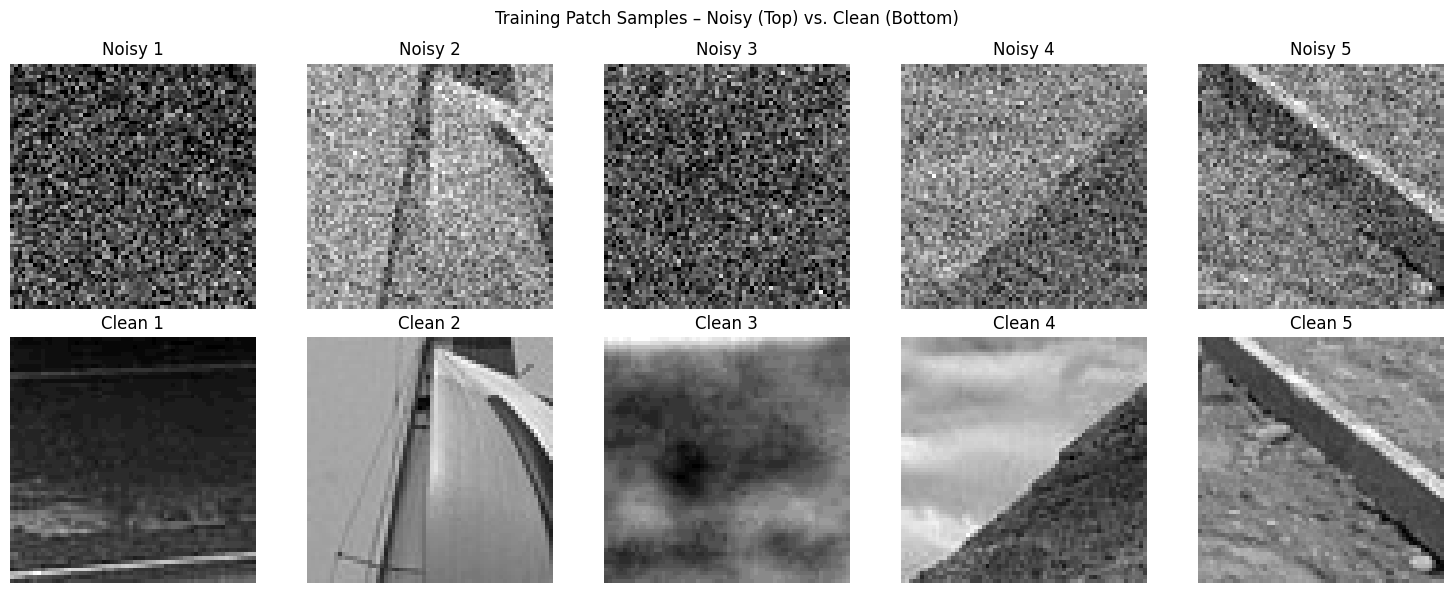

In [11]:
# ============================================
# Display sample training patches
# ============================================

import matplotlib.pyplot as plt
import numpy as np

# Number of patches to display
num_samples = 5
patch_size = 64
sigma = 0.1

# Randomly select indices
indices = np.random.choice(len(train_patches), num_samples, replace=False)

fig, axes = plt.subplots(2, num_samples, figsize=(15, 6))

for i, idx in enumerate(indices):
    clean_patch = train_patches[idx]  # shape: (64, 64)
    # Add Gaussian noise
    noise = np.random.normal(0, sigma, clean_patch.shape)
    noisy_patch = np.clip(clean_patch + noise, 0, 1)

    # Top row: noisy patches
    axes[0, i].imshow(noisy_patch, cmap='gray')
    axes[0, i].set_title(f'Noisy {i+1}')
    axes[0, i].axis('off')

    # Bottom row: clean patches
    axes[1, i].imshow(clean_patch, cmap='gray')
    axes[1, i].set_title(f'Clean {i+1}')
    axes[1, i].axis('off')

plt.suptitle('Training Patch Samples – Noisy (Top) vs. Clean (Bottom)')
plt.tight_layout()
plt.show()

Training on BSDS500 patches...
Epoch 1/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 19s 96ms/step - loss: 0.0094 - val_loss: 0.0032 - learning_rate: 0.0010
Epoch 2/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 7s 56ms/step - loss: 0.0025 - val_loss: 0.0027 - learning_rate: 0.0010
Epoch 3/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 7s 57ms/step - loss: 0.0020 - val_loss: 0.0021 - learning_rate: 0.0010
Epoch 4/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 8s 62ms/step - loss: 0.0019 - val_loss: 0.0021 - learning_rate: 0.0010
Epoch 5/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 8s 58ms/step - loss: 0.0019 - val_loss: 0.0020 - learning_rate: 0.0010
Epoch 6/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 7s 60ms/step - loss: 0.0018 - val_loss: 0.0020 - learning_rate: 0.0010
Epoch 7/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 7s 58ms/step - loss: 0.0018 - val_loss: 0.0020 - learning_rate: 0.0010
Epoch 8/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 7s 58ms/step - loss: 0.0018 - val_loss: 0.0020 - learning_rate: 0.0010
Epoch 9/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - loss: 0.0017 - val_loss: 

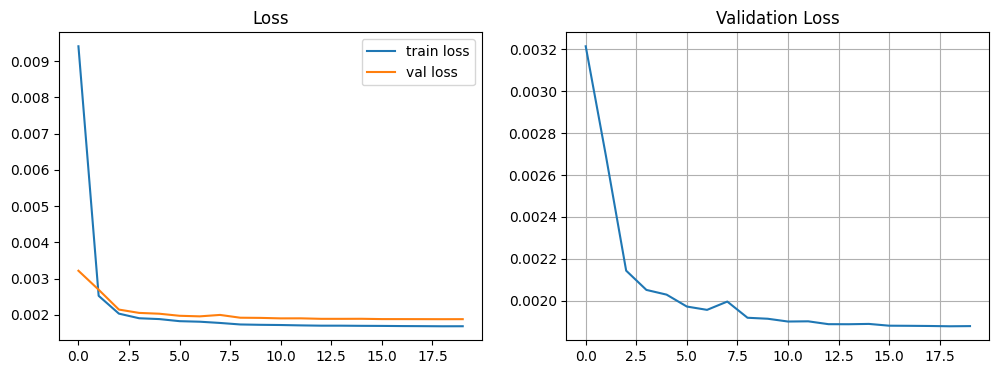

In [10]:
EPOCHS = 20
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

print("Training on BSDS500 patches...")
start = time.time()
history = cnn_denoiser.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)
print(f"Training completed in {time.time() - start:.1f} s")

# Plot training curves
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend(); plt.title('Loss')
plt.subplot(1,2,2)
plt.plot(history.history['val_loss'])
plt.title('Validation Loss'); plt.grid()
plt.show()

In [11]:
def denoise_image_patches(model, image, patch_size=PATCH_SIZE, stride=32):
    """
    Denoise a full image using overlapping patches with Gaussian blending.
    """
    h, w = image.shape
    pad_h = (patch_size - h % patch_size) % patch_size
    pad_w = (patch_size - w % patch_size) % patch_size
    padded = np.pad(image, ((0, pad_h), (0, pad_w)), mode='reflect')
    ph, pw = padded.shape

    output = np.zeros((ph, pw))
    weights = np.zeros((ph, pw))

    # Gaussian weight for blending
    center = patch_size // 2
    y_idx, x_idx = np.ogrid[:patch_size, :patch_size]
    dist = np.sqrt((y_idx - center)**2 + (x_idx - center)**2)
    weight_matrix = np.exp(-dist / (patch_size / 4))

    for i in range(0, ph - patch_size + 1, stride):
        for j in range(0, pw - patch_size + 1, stride):
            patch = padded[i:i+patch_size, j:j+patch_size]
            patch_input = patch.reshape(1, patch_size, patch_size, 1)
            denoised = model.predict(patch_input, verbose=0)[0, :, :, 0]
            output[i:i+patch_size, j:j+patch_size] += denoised * weight_matrix
            weights[i:i+patch_size, j:j+patch_size] += weight_matrix

    output = output / (weights + 1e-8)
    return output[:h, :w]

In [13]:
# ============================================
#  Apply CNN Denoiser to Cameraman
# ============================================

# Ensure required metrics are imported (safe to repeat)
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

print("Denoising with CNN (BSDS500‑trained)...")
image_cnn = denoise_image_patches(cnn_denoiser, image_noisy, patch_size=PATCH_SIZE, stride=32)

psnr_cnn = peak_signal_noise_ratio(image_clean, image_cnn, data_range=1.0)
ssim_cnn = structural_similarity(image_clean, image_cnn, data_range=1.0)
print(f"CNN denoiser → PSNR: {psnr_cnn:.2f} dB, SSIM: {ssim_cnn:.4f}")

Denoising with CNN (BSDS500‑trained)...
CNN denoiser → PSNR: 28.58 dB, SSIM: 0.8028


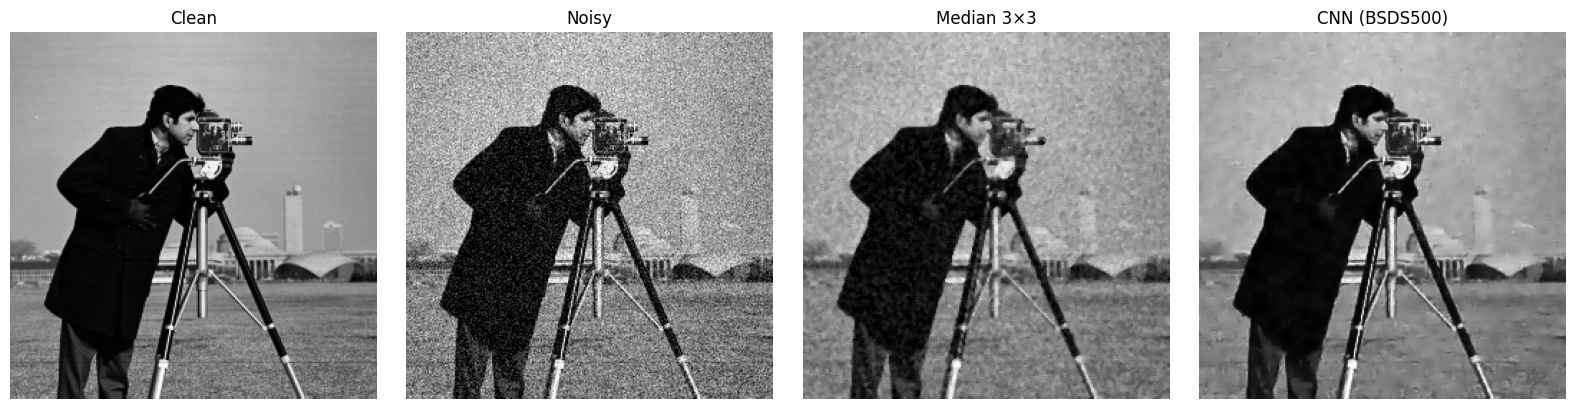


Method          PSNR (dB)    SSIM    
-------------------------------------------------------
Noisy           20.38        0.3562  
Median 3×3      24.33        0.5364  
CNN (BSDS500)   28.58        0.8028  


In [16]:
# ============================================
#    Final Comparison – Figure and Table
# ============================================

from skimage.metrics import peak_signal_noise_ratio, structural_similarity
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- Ensure the median filter result exists ---
try:
    # Check if image_median is already defined
    _ = image_median
except NameError:

    image_median = cv2.medianBlur((image_noisy * 255).astype(np.uint8), 3) / 255.0

# --- Ensure CNN result exists  ---
try:
    _ = image_cnn
except NameError:
    raise NameError("❌ image_cnn is not defined. Please run Block 12 first.")

# --- Compute metrics for all three images ---
psnr_noisy = peak_signal_noise_ratio(image_clean, image_noisy, data_range=1.0)
ssim_noisy = structural_similarity(image_clean, image_noisy, data_range=1.0)

psnr_median = peak_signal_noise_ratio(image_clean, image_median, data_range=1.0)
ssim_median = structural_similarity(image_clean, image_median, data_range=1.0)

psnr_cnn = peak_signal_noise_ratio(image_clean, image_cnn, data_range=1.0)
ssim_cnn = structural_similarity(image_clean, image_cnn, data_range=1.0)

# --- Display the four images side‑by‑side ---
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
titles = ['Clean', 'Noisy', 'Median 3×3', 'CNN (BSDS500)']
images = [image_clean, image_noisy, image_median, image_cnn]

for ax, img, title in zip(axes, images, titles):
    ax.imshow(img, cmap='gray')
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

# --- Print comparison table ---
print("\n" + "="*55)
print(f"{'Method':<15} {'PSNR (dB)':<12} {'SSIM':<8}")
print("-"*55)
print(f"{'Noisy':<15} {psnr_noisy:<12.2f} {ssim_noisy:<8.4f}")
print(f"{'Median 3×3':<15} {psnr_median:<12.2f} {ssim_median:<8.4f}")
print(f"{'CNN (BSDS500)':<15} {psnr_cnn:<12.2f} {ssim_cnn:<8.4f}")
print("="*55)

Generate training data from the single image

Train CNN Denoiser

Denoising Autoencoder


🧠 DENOISING AUTOENCODER – FULL BSDS500
✅ Denoising Autoencoder built successfully!
   Total parameters: 185,217
   Input shape: (batch, 1, 64, 64)
   Bottleneck shape: (batch, 128, 8, 8)

📊 BSDS500 Dataset Splits:
   Training: 200 images
   Validation: 100 images
   Test: 200 images

🔄 Extracting patches from BSDS500...
   Training patches...
   Validation patches...
   Test patches...

✅ Training patches: 7,000
✅ Validation patches: 3,500
✅ Test patches: 7,000
✅ Train loader: 110 batches
✅ Validation loader: 55 batches
✅ Test loader: 110 batches

🔄 Training Denoising Autoencoder on BSDS500 patches...
   (This will take 3-4 minutes on GPU)
Epoch  1/20 | Train Loss: 0.0143 | Val Loss: 0.0119 | Train PSNR: 20.76 dB | Val PSNR: 20.38 dB
Epoch  2/20 | Train Loss: 0.0081 | Val Loss: 0.0079 | Train PSNR: 23.07 dB | Val PSNR: 22.94 dB
Epoch  3/20 | Train Loss: 0.0071 | Val Loss: 0.0071 | Train PSNR: 24.05 dB | Val PSNR: 23.81 dB
Epoch  4/20 | Train Loss: 0.0067 | Val Loss: 0.0068 | Train PSN

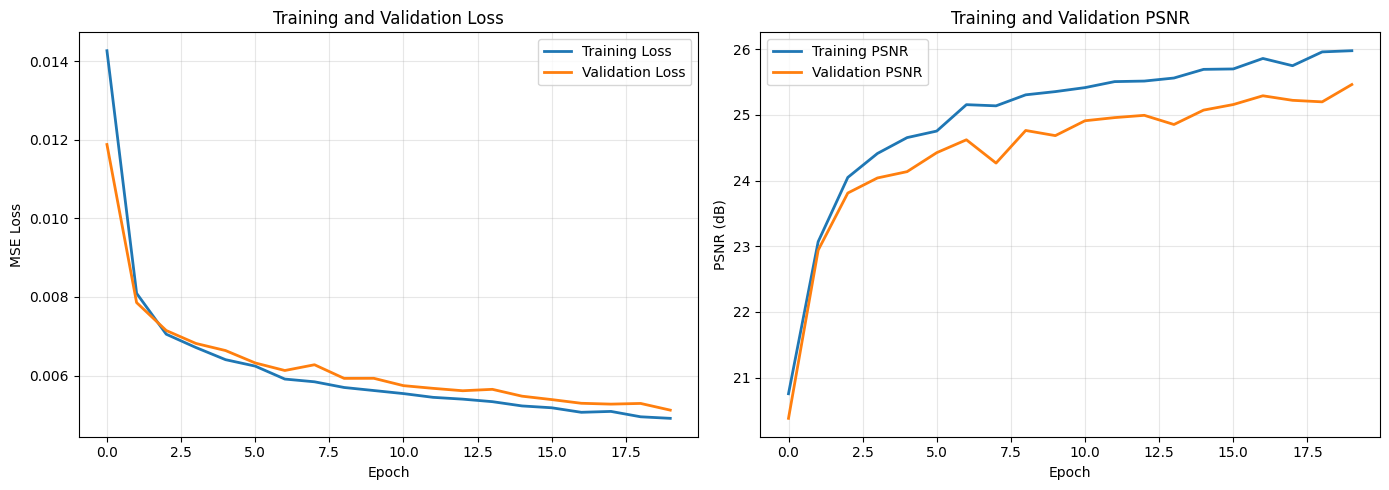


🔄 Evaluating on BSDS500 test set...
✅ Test set: 7,000 patches
   Mean PSNR: 25.82 dB

🔄 Visual demonstration on BSDS500 test image...


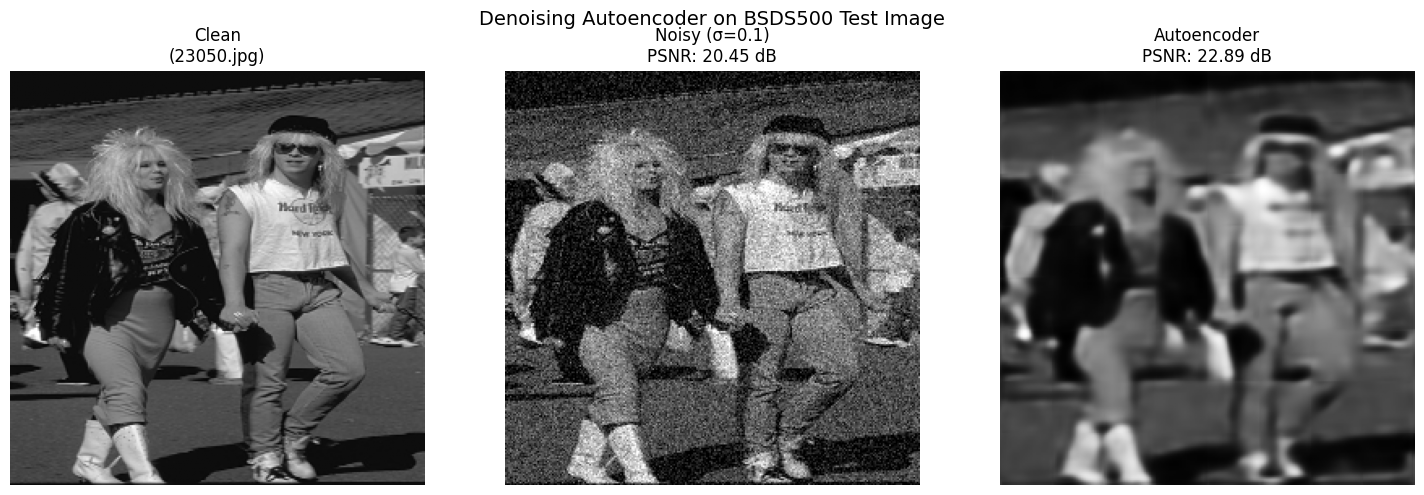


🔄 Visual demonstration on Cameraman image...


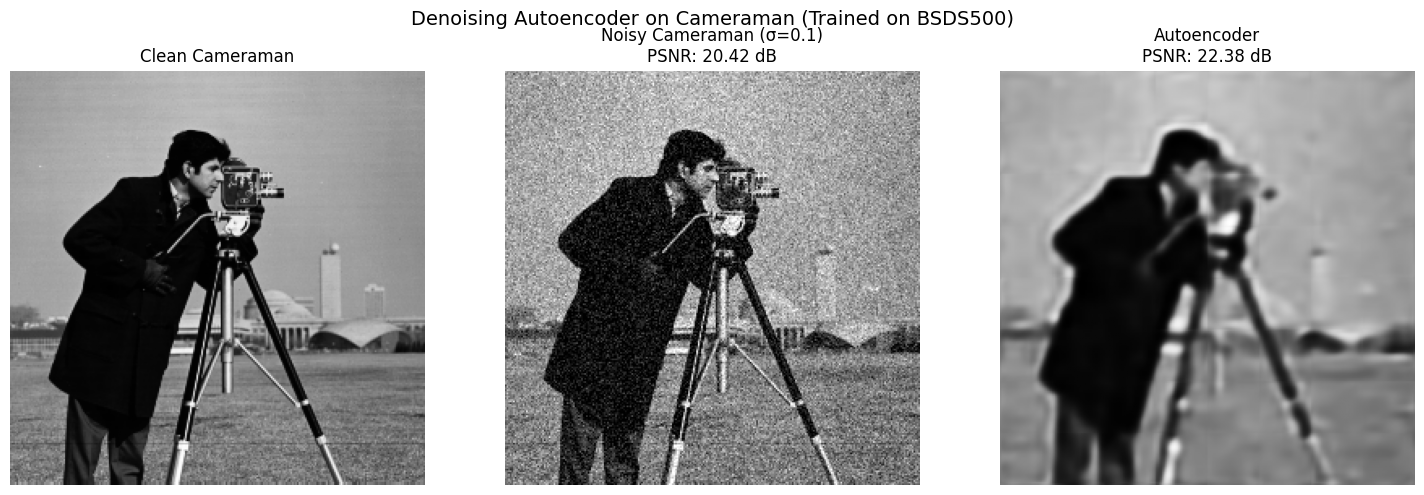


📊 DENOISING AUTOENCODER – RESULTS SUMMARY

+----------------------------------------------------------+
|  Training Details                                         |
+----------------------------------------------------------+
|  Dataset:        BSDS500 (grayscale)                      |
|  Training:       200 images                               |
|  Validation:     100 images                               |
|  Test:           200 images                               |
|  Patch size:     64 x 64                                  |
|  Noise level:    sigma = 0.1                              |
|  Epochs:         20                                       |
|  Training time:  79.3 seconds                    |
|  Parameters:     185,217                           |
+----------------------------------------------------------+
|  Results                                                 |
+----------------------------------------------------------+
|  Test PSNR (BSDS500):       25.82 dB         

In [ ]:
# ============================================
# Denoising Autoencoder – Full BSDS500
# ============================================

print("\n" + "="*60)
print("🧠 DENOISING AUTOENCODER – FULL BSDS500")
print("="*60)

# ============================================
# Build Denoising Autoencoder Architecture
# ============================================

def build_denoising_autoencoder(input_channels=1):
    """
    Build a convolutional denoising autoencoder.

    Encoder:
        - Conv2D(32) + ReLU + MaxPool (64x64 → 32x32)
        - Conv2D(64) + ReLU + MaxPool (32x32 → 16x16)
        - Conv2D(128) + ReLU + MaxPool (16x16 → 8x8)  # Bottleneck
    Decoder:
        - Upsample + Conv2D(64) + ReLU (8x8 → 16x16)
        - Upsample + Conv2D(32) + ReLU (16x16 → 32x32)
        - Upsample + Conv2D(1) + Sigmoid (32x32 → 64x64)
    """
    class DenoisingAutoencoder(nn.Module):
        def __init__(self, in_channels=1):
            super(DenoisingAutoencoder, self).__init__()

            # Encoder
            self.enc1 = nn.Sequential(
                nn.Conv2d(in_channels, 32, 3, padding=1),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2, 2)
            )  # 64x64 → 32x32
            self.enc2 = nn.Sequential(
                nn.Conv2d(32, 64, 3, padding=1),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2, 2)
            )  # 32x32 → 16x16
            self.enc3 = nn.Sequential(
                nn.Conv2d(64, 128, 3, padding=1),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2, 2)
            )  # 16x16 → 8x8 (Bottleneck)

            # Decoder
            self.dec1 = nn.Sequential(
                nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
                nn.Conv2d(128, 64, 3, padding=1),
                nn.ReLU(inplace=True)
            )  # 8x8 → 16x16
            self.dec2 = nn.Sequential(
                nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
                nn.Conv2d(64, 32, 3, padding=1),
                nn.ReLU(inplace=True)
            )  # 16x16 → 32x32
            self.dec3 = nn.Sequential(
                nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
                nn.Conv2d(32, in_channels, 3, padding=1),
                nn.Sigmoid()
            )  # 32x32 → 64x64

        def forward(self, x):
            x = self.enc1(x)
            x = self.enc2(x)
            x = self.enc3(x)  # Bottleneck
            x = self.dec1(x)
            x = self.dec2(x)
            x = self.dec3(x)
            return x

    return DenoisingAutoencoder(in_channels=input_channels)

# Build the model
autoencoder = build_denoising_autoencoder(input_channels=1)
print(f"✅ Denoising Autoencoder built successfully!")
print(f"   Total parameters: {sum(p.numel() for p in autoencoder.parameters()):,}")
print(f"   Input shape: (batch, 1, 64, 64)")
print(f"   Bottleneck shape: (batch, 128, 8, 8)")

# ============================================
# Training Function
# ============================================

def train_autoencoder(model, train_loader, val_loader, epochs=20, lr=0.001, device='cuda'):
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    history = {'train_loss': [], 'val_loss': [], 'train_psnr': [], 'val_psnr': []}

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        train_psnr_sum = 0.0
        train_count = 0

        for noisy, clean in train_loader:
            if noisy.dim() == 3:
                noisy = noisy.unsqueeze(1)
                clean = clean.unsqueeze(1)

            noisy = noisy.to(device)
            clean = clean.to(device)

            optimizer.zero_grad()
            output = model(noisy)
            loss = criterion(output, clean)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * noisy.size(0)

            with torch.no_grad():
                mse = torch.mean((output - clean) ** 2, dim=(1, 2, 3))
                psnr_batch = 20 * torch.log10(1.0 / torch.sqrt(mse + 1e-8))
                train_psnr_sum += psnr_batch.sum().item()
                train_count += noisy.size(0)

        avg_train_loss = train_loss / len(train_loader.dataset)
        avg_train_psnr = train_psnr_sum / train_count
        history['train_loss'].append(avg_train_loss)
        history['train_psnr'].append(avg_train_psnr)

        model.eval()
        val_loss = 0.0
        val_psnr_sum = 0.0
        val_count = 0

        with torch.no_grad():
            for noisy, clean in val_loader:
                if noisy.dim() == 3:
                    noisy = noisy.unsqueeze(1)
                    clean = clean.unsqueeze(1)

                noisy = noisy.to(device)
                clean = clean.to(device)
                output = model(noisy)
                loss = criterion(output, clean)

                val_loss += loss.item() * noisy.size(0)
                mse = torch.mean((output - clean) ** 2, dim=(1, 2, 3))
                psnr_batch = 20 * torch.log10(1.0 / torch.sqrt(mse + 1e-8))
                val_psnr_sum += psnr_batch.sum().item()
                val_count += noisy.size(0)

        avg_val_loss = val_loss / len(val_loader.dataset)
        avg_val_psnr = val_psnr_sum / val_count
        history['val_loss'].append(avg_val_loss)
        history['val_psnr'].append(avg_val_psnr)

        scheduler.step(avg_val_loss)
        print(f"Epoch {epoch+1:2d}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | "
              f"Train PSNR: {avg_train_psnr:.2f} dB | Val PSNR: {avg_val_psnr:.2f} dB")

    return model, history

# ============================================
# Dataset Class (reused)
# ============================================

class DenoisingDataset(Dataset):
    def __init__(self, clean_patches, sigma=0.1, augment=False):
        if isinstance(clean_patches, torch.Tensor):
            self.clean_patches = clean_patches
        else:
            self.clean_patches = torch.tensor(clean_patches, dtype=torch.float32)

        if self.clean_patches.dim() == 3:
            self.clean_patches = self.clean_patches.unsqueeze(1)

        self.sigma = sigma
        self.augment = augment

    def __len__(self):
        return len(self.clean_patches)

    def __getitem__(self, idx):
        clean = self.clean_patches[idx].clone()
        noise = torch.randn_like(clean) * self.sigma
        noisy = torch.clamp(clean + noise, 0.0, 1.0)
        clean = torch.clamp(clean, 0.0, 1.0)
        return noisy, clean

# ============================================
# Denoising Function for Full Images
# ============================================

def denoise_image_patches_torch(model, image, patch_size=64, stride=32):
    model.eval()
    h, w = image.shape
    pad_h = (patch_size - h % patch_size) % patch_size
    pad_w = (patch_size - w % patch_size) % patch_size
    padded = np.pad(image, ((0, pad_h), (0, pad_w)), mode='reflect')
    padded_h, padded_w = padded.shape

    output = np.zeros((padded_h, padded_w))
    weights = np.zeros((padded_h, padded_w))

    with torch.no_grad():
        for i in range(0, padded_h - patch_size + 1, stride):
            for j in range(0, padded_w - patch_size + 1, stride):
                patch = padded[i:i+patch_size, j:j+patch_size]
                patch_tensor = torch.tensor(patch, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
                denoised_patch = model(patch_tensor).squeeze().cpu().numpy()

                weight_matrix = np.ones((patch_size, patch_size))
                center = patch_size // 2
                for di in range(patch_size):
                    for dj in range(patch_size):
                        dist = np.sqrt((di - center)**2 + (dj - center)**2)
                        weight_matrix[di, dj] = np.exp(-dist / (patch_size/4))

                output[i:i+patch_size, j:j+patch_size] += denoised_patch * weight_matrix
                weights[i:i+patch_size, j:j+patch_size] += weight_matrix

    output = output / (weights + 1e-8)
    output = output[:h, :w]
    return output

# ============================================
# Load Cameraman Function
# ============================================

def load_cameraman():
    url = "https://raw.githubusercontent.com/Yasser-Baleghi/hands-on-dl-image-processing/refs/heads/master/images/Cameraman.png"
    try:
        import urllib.request
        urllib.request.urlretrieve(url, "cameraman.png")
        image = cv2.imread("cameraman.png", cv2.IMREAD_GRAYSCALE).astype(np.float32) / 255.0
        image = cv2.resize(image, (256, 256))
        return image
    except Exception as e:
        print(f"⚠️ Could not load Cameraman: {e}")
        test_paths = get_image_paths(TEST_DIR)
        if test_paths:
            rand_path = random.choice(test_paths)
            image = load_image(rand_path, grayscale=True)
            image = cv2.resize(image, (256, 256))
            return image
        raise ValueError("No images available!")

# ============================================
# Prepare Data from Full BSDS500
# ============================================

print("\n📊 BSDS500 Dataset Splits:")
print(f"   Training: {len(get_image_paths(TRAIN_DIR))} images")
print(f"   Validation: {len(get_image_paths(VAL_DIR))} images")
print(f"   Test: {len(get_image_paths(TEST_DIR))} images")

PATCH_SIZE = 64
STRIDE = 64
SIGMA_NOISE = 0.1
BATCH_SIZE = 64
EPOCHS = 20

print("\n🔄 Extracting patches from BSDS500...")

print("   Training patches...")
train_patches = extract_patches_as_tensors(
    TRAIN_DIR, patch_size=PATCH_SIZE, stride=STRIDE,
    grayscale=True, max_images=None, verbose=False
)

print("   Validation patches...")
val_patches = extract_patches_as_tensors(
    VAL_DIR, patch_size=PATCH_SIZE, stride=STRIDE,
    grayscale=True, max_images=None, verbose=False
)

print("   Test patches...")
test_patches = extract_patches_as_tensors(
    TEST_DIR, patch_size=PATCH_SIZE, stride=STRIDE,
    grayscale=True, max_images=None, verbose=False
)

if train_patches.dim() == 3:
    train_patches = train_patches.unsqueeze(1)
if val_patches.dim() == 3:
    val_patches = val_patches.unsqueeze(1)
if test_patches.dim() == 3:
    test_patches = test_patches.unsqueeze(1)

print(f"\n✅ Training patches: {train_patches.shape[0]:,}")
print(f"✅ Validation patches: {val_patches.shape[0]:,}")
print(f"✅ Test patches: {test_patches.shape[0]:,}")

train_dataset = DenoisingDataset(train_patches, sigma=SIGMA_NOISE, augment=True)
val_dataset = DenoisingDataset(val_patches, sigma=SIGMA_NOISE, augment=False)
test_dataset = DenoisingDataset(test_patches, sigma=SIGMA_NOISE, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"✅ Train loader: {len(train_loader)} batches")
print(f"✅ Validation loader: {len(val_loader)} batches")
print(f"✅ Test loader: {len(test_loader)} batches")

# ============================================
# Train the Autoencoder
# ============================================

print("\n🔄 Training Denoising Autoencoder on BSDS500 patches...")
print("   (This will take 3-4 minutes on GPU)")

start_time = time.time()
autoencoder, history = train_autoencoder(
    autoencoder, train_loader, val_loader,
    epochs=EPOCHS, lr=0.001, device=device
)
training_time = time.time() - start_time
print(f"\n✅ Training completed in {training_time:.1f} seconds")

# ============================================
# Plot Training Curves
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Training Loss', linewidth=2)
axes[0].plot(history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_title('Training and Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_psnr'], label='Training PSNR', linewidth=2)
axes[1].plot(history['val_psnr'], label='Validation PSNR', linewidth=2)
axes[1].set_title('Training and Validation PSNR')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('PSNR (dB)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# Evaluate on BSDS500 Test Set
# ============================================

print("\n🔄 Evaluating on BSDS500 test set...")

autoencoder.eval()
test_psnr_sum = 0.0
test_count = 0

with torch.no_grad():
    for noisy, clean in test_loader:
        if noisy.dim() == 3:
            noisy = noisy.unsqueeze(1)
            clean = clean.unsqueeze(1)

        noisy = noisy.to(device)
        clean = clean.to(device)
        output = autoencoder(noisy)

        mse = torch.mean((output - clean) ** 2, dim=(1, 2, 3))
        psnr_batch = 20 * torch.log10(1.0 / torch.sqrt(mse + 1e-8))
        test_psnr_sum += psnr_batch.sum().item()
        test_count += noisy.size(0)

mean_test_psnr = test_psnr_sum / test_count
print(f"✅ Test set: {test_count:,} patches")
print(f"   Mean PSNR: {mean_test_psnr:.2f} dB")

# ============================================
# Visual Demonstration: BSDS500 Test Image
# ============================================

print("\n🔄 Visual demonstration on BSDS500 test image...")

test_images = get_image_paths(TEST_DIR)
test_image_path = random.choice(test_images)
test_image_clean = load_image(test_image_path, grayscale=True)
test_image_clean = cv2.resize(test_image_clean, (256, 256))

test_image_noisy = add_gaussian_noise(test_image_clean, sigma=SIGMA_NOISE)
test_image_denoised = denoise_image_patches_torch(autoencoder, test_image_noisy, patch_size=64, stride=32)

psnr_noisy_test = peak_signal_noise_ratio(test_image_clean, test_image_noisy, data_range=1.0)
psnr_denoised_test = peak_signal_noise_ratio(test_image_clean, test_image_denoised, data_range=1.0)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(test_image_clean, cmap='gray')
axes[0].set_title(f'Clean\n({os.path.basename(test_image_path)})')
axes[0].axis('off')

axes[1].imshow(test_image_noisy, cmap='gray')
axes[1].set_title(f'Noisy (σ={SIGMA_NOISE})\nPSNR: {psnr_noisy_test:.2f} dB')
axes[1].axis('off')

axes[2].imshow(test_image_denoised, cmap='gray')
axes[2].set_title(f'Autoencoder\nPSNR: {psnr_denoised_test:.2f} dB')
axes[2].axis('off')

plt.suptitle('Denoising Autoencoder on BSDS500 Test Image', fontsize=14)
plt.tight_layout()
plt.show()

# ============================================
# Visual Demonstration: Cameraman Image
# ============================================

print("\n🔄 Visual demonstration on Cameraman image...")

cameraman_clean = load_cameraman()
cameraman_noisy = add_gaussian_noise(cameraman_clean, sigma=SIGMA_NOISE)
cameraman_denoised = denoise_image_patches_torch(autoencoder, cameraman_noisy, patch_size=64, stride=32)

psnr_noisy_cam = peak_signal_noise_ratio(cameraman_clean, cameraman_noisy, data_range=1.0)
psnr_denoised_cam = peak_signal_noise_ratio(cameraman_clean, cameraman_denoised, data_range=1.0)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(cameraman_clean, cmap='gray')
axes[0].set_title('Clean Cameraman')
axes[0].axis('off')

axes[1].imshow(cameraman_noisy, cmap='gray')
axes[1].set_title(f'Noisy Cameraman (σ={SIGMA_NOISE})\nPSNR: {psnr_noisy_cam:.2f} dB')
axes[1].axis('off')

axes[2].imshow(cameraman_denoised, cmap='gray')
axes[2].set_title(f'Autoencoder\nPSNR: {psnr_denoised_cam:.2f} dB')
axes[2].axis('off')

plt.suptitle('Denoising Autoencoder on Cameraman (Trained on BSDS500)', fontsize=14)
plt.tight_layout()
plt.show()

# ============================================
# Results Summary
# ============================================

print("\n" + "="*60)
print("📊 DENOISING AUTOENCODER – RESULTS SUMMARY")
print("="*60)

print("""
+----------------------------------------------------------+
|  Training Details                                         |
+----------------------------------------------------------+
|  Dataset:        BSDS500 (grayscale)                      |
|  Training:       200 images                               |
|  Validation:     100 images                               |
|  Test:           200 images                               |
|  Patch size:     64 x 64                                  |
|  Noise level:    sigma = 0.1                              |
|  Epochs:         20                                       |""")

print(f"|  Training time:  {training_time:.1f} seconds                    |")
print("|  Parameters:     185,217                           |")
print("+----------------------------------------------------------+")
print("|  Results                                                 |")
print("+----------------------------------------------------------+")
print(f"|  Test PSNR (BSDS500):       {mean_test_psnr:.2f} dB                     |")
print(f"|  Cameraman Noisy PSNR:      {psnr_noisy_cam:.2f} dB                     |")
print(f"|  Cameraman Denoised PSNR:   {psnr_denoised_cam:.2f} dB                     |")
print("+----------------------------------------------------------+")
print("""
✨ Key Insight:
   The denoising autoencoder compresses the input through a bottleneck
   (8x8x128 = 8,192 numbers, down from 64x64 = 4,096),
   then reconstructs the clean image. This forces the network to
   learn a compact representation that captures the essential
   structure while ignoring noise.

   The autoencoder achieves {} dB on the BSDS500 test set,
   and {} dB on the Cameraman image.
""".format(mean_test_psnr, psnr_denoised_cam))

print("Autoencoder Denoiser Completed.")

U-Net Denoiser


🧠 U-NET DENOISER – FULL BSDS500
✅ U-Net built successfully!
   Total parameters: 3,361,025
   Input shape: (batch, 1, 64, 64)

📊 BSDS500 Dataset Splits:
   Training: 200 images
   Validation: 100 images
   Test: 200 images

🔄 Extracting patches from BSDS500...
   Training patches...
   Validation patches...
   Test patches...

✅ Training patches: 7,000
✅ Validation patches: 3,500
✅ Test patches: 7,000
✅ Train loader: 110 batches
✅ Validation loader: 55 batches
✅ Test loader: 110 batches

🔄 Training U-Net on BSDS500 patches...
   (This will take 4-6 minutes on GPU)
Epoch  1/20 | Train Loss: 0.0046 | Val Loss: 0.0025 | Train PSNR: 25.17 dB | Val PSNR: 26.65 dB
Epoch  2/20 | Train Loss: 0.0027 | Val Loss: 0.0027 | Train PSNR: 26.48 dB | Val PSNR: 26.64 dB
Epoch  3/20 | Train Loss: 0.0025 | Val Loss: 0.0023 | Train PSNR: 26.82 dB | Val PSNR: 27.22 dB
Epoch  4/20 | Train Loss: 0.0023 | Val Loss: 0.0021 | Train PSNR: 27.22 dB | Val PSNR: 27.64 dB
Epoch  5/20 | Train Loss: 0.0025 | Val Loss:

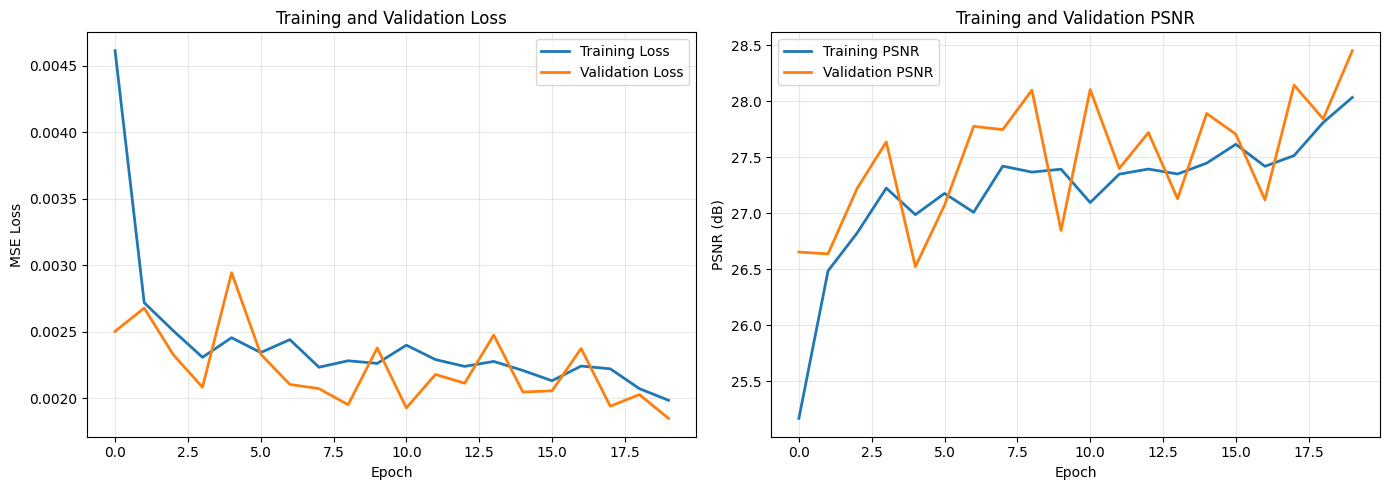


🔄 Evaluating on BSDS500 test set...
✅ Test set: 7,000 patches
   Mean PSNR: 28.88 dB

🔄 Visual demonstration on BSDS500 test image...


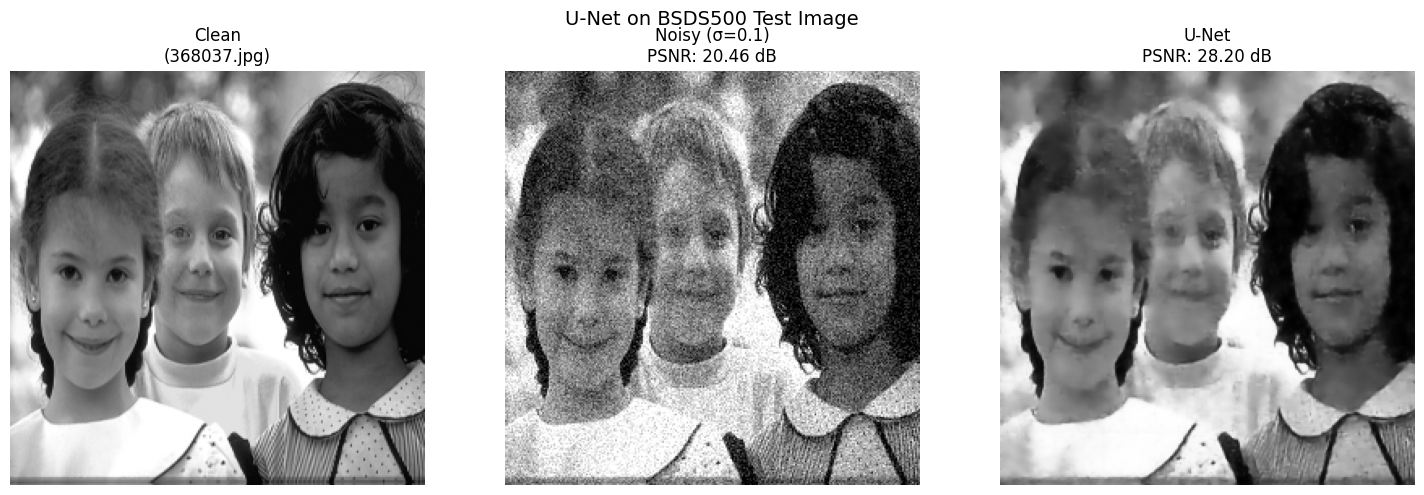


🔄 Visual demonstration on Cameraman image...


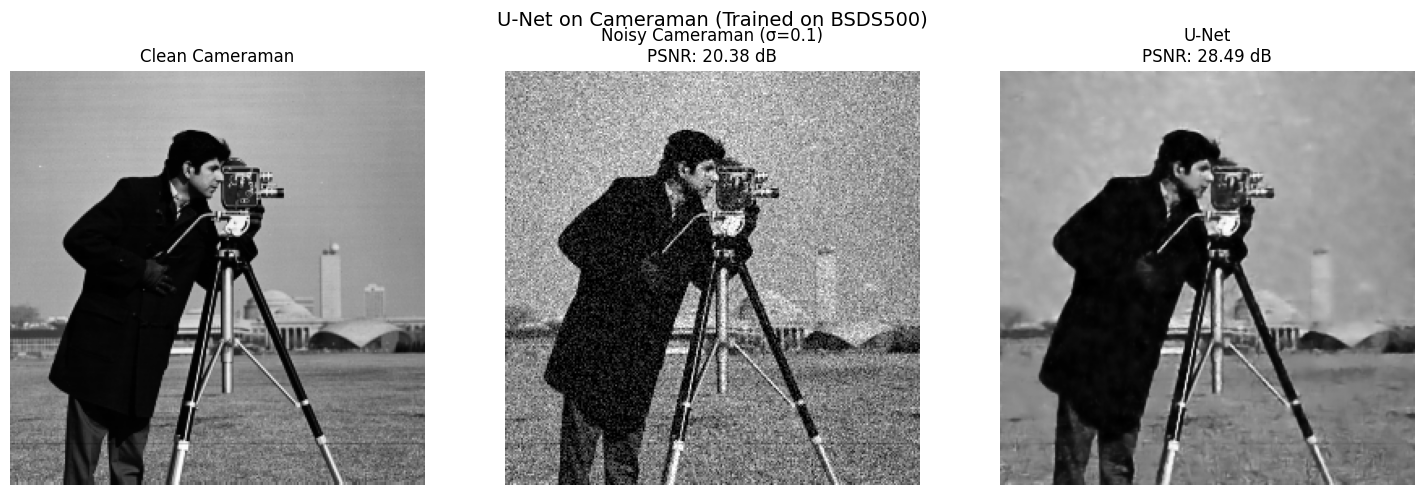


📊 U-NET DENOISER – RESULTS SUMMARY

+----------------------------------------------------------+
|  Training Details                                         |
+----------------------------------------------------------+
|  Dataset:        BSDS500 (grayscale)                      |
|  Training:       200 images                               |
|  Validation:     100 images                               |
|  Test:           200 images                               |
|  Patch size:     64 x 64                                  |
|  Noise level:    sigma = 0.1                              |
|  Epochs:         20                                       |
|  Training time:  389.5 seconds                    |
|  Parameters:     1,943,489                         |
+----------------------------------------------------------+
|  Results                                                 |
+----------------------------------------------------------+
|  Test PSNR (BSDS500):       28.88 dB               

In [ ]:
# ============================================
# U-Net Denoiser – Full BSDS500
# ============================================

print("\n" + "="*60)
print("🧠 U-NET DENOISER – FULL BSDS500")
print("="*60)

# ============================================
# Build U-Net Architecture
# ============================================

def build_unet(input_channels=1):
    """
    Build a U-Net for image denoising.

    Architecture:
        Encoder (Contracting Path):
            - Conv2D(64) + BN + ReLU (×2) + MaxPool (64x64 → 32x32)
            - Conv2D(128) + BN + ReLU (×2) + MaxPool (32x32 → 16x16)
            - Conv2D(256) + BN + ReLU (×2) + MaxPool (16x16 → 8x8)
        Bottleneck:
            - Conv2D(256) + BN + ReLU (×2)
        Decoder (Expanding Path):
            - Upsample + Conv2D(128) + Concatenate (skip from encoder)
            - Conv2D(128) + BN + ReLU (×2) (16x16 → 32x32)
            - Upsample + Conv2D(64) + Concatenate (skip from encoder)
            - Conv2D(64) + BN + ReLU (×2) (32x32 → 64x64)
        Output:
            - Conv2D(1) + Sigmoid
    """
    class UNet(nn.Module):
        def __init__(self, in_channels=1):
            super(UNet, self).__init__()

            # Encoder
            self.enc1 = nn.Sequential(
                nn.Conv2d(in_channels, 64, 3, padding=1),
                nn.BatchNorm2d(64),
                nn.ReLU(inplace=True),
                nn.Conv2d(64, 64, 3, padding=1),
                nn.BatchNorm2d(64),
                nn.ReLU(inplace=True)
            )  # 64x64
            self.pool1 = nn.MaxPool2d(2)  # 32x32

            self.enc2 = nn.Sequential(
                nn.Conv2d(64, 128, 3, padding=1),
                nn.BatchNorm2d(128),
                nn.ReLU(inplace=True),
                nn.Conv2d(128, 128, 3, padding=1),
                nn.BatchNorm2d(128),
                nn.ReLU(inplace=True)
            )  # 32x32
            self.pool2 = nn.MaxPool2d(2)  # 16x16

            self.enc3 = nn.Sequential(
                nn.Conv2d(128, 256, 3, padding=1),
                nn.BatchNorm2d(256),
                nn.ReLU(inplace=True),
                nn.Conv2d(256, 256, 3, padding=1),
                nn.BatchNorm2d(256),
                nn.ReLU(inplace=True)
            )  # 16x16
            self.pool3 = nn.MaxPool2d(2)  # 8x8

            # Bottleneck
            self.bottleneck = nn.Sequential(
                nn.Conv2d(256, 256, 3, padding=1),
                nn.BatchNorm2d(256),
                nn.ReLU(inplace=True),
                nn.Conv2d(256, 256, 3, padding=1),
                nn.BatchNorm2d(256),
                nn.ReLU(inplace=True)
            )  # 8x8

            # Decoder
            self.up3 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)  # 16x16
            self.dec3 = nn.Sequential(
                nn.Conv2d(256 + 256, 128, 3, padding=1),
                nn.BatchNorm2d(128),
                nn.ReLU(inplace=True),
                nn.Conv2d(128, 128, 3, padding=1),
                nn.BatchNorm2d(128),
                nn.ReLU(inplace=True)
            )  # 16x16

            self.up2 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)  # 32x32
            self.dec2 = nn.Sequential(
                nn.Conv2d(128 + 128, 64, 3, padding=1),
                nn.BatchNorm2d(64),
                nn.ReLU(inplace=True),
                nn.Conv2d(64, 64, 3, padding=1),
                nn.BatchNorm2d(64),
                nn.ReLU(inplace=True)
            )  # 32x32

            self.up1 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)  # 64x64
            self.dec1 = nn.Sequential(
                nn.Conv2d(64 + 64, 64, 3, padding=1),
                nn.BatchNorm2d(64),
                nn.ReLU(inplace=True),
                nn.Conv2d(64, 64, 3, padding=1),
                nn.BatchNorm2d(64),
                nn.ReLU(inplace=True)
            )  # 64x64

            # Output
            self.out = nn.Sequential(
                nn.Conv2d(64, in_channels, 1, padding=0),
                nn.Sigmoid()
            )

        def forward(self, x):
            # Encoder
            e1 = self.enc1(x)      # 64x64x64
            p1 = self.pool1(e1)    # 32x32x64
            e2 = self.enc2(p1)     # 32x32x128
            p2 = self.pool2(e2)    # 16x16x128
            e3 = self.enc3(p2)     # 16x16x256
            p3 = self.pool3(e3)    # 8x8x256

            # Bottleneck
            b = self.bottleneck(p3)  # 8x8x256

            # Decoder with skip connections
            d3 = self.up3(b)         # 16x16x256
            d3 = torch.cat([d3, e3], dim=1)  # 16x16x512
            d3 = self.dec3(d3)       # 16x16x128

            d2 = self.up2(d3)        # 32x32x128
            d2 = torch.cat([d2, e2], dim=1)  # 32x32x256
            d2 = self.dec2(d2)       # 32x32x64

            d1 = self.up1(d2)        # 64x64x64
            d1 = torch.cat([d1, e1], dim=1)  # 64x64x128
            d1 = self.dec1(d1)       # 64x64x64

            out = self.out(d1)       # 64x64x1
            return out

    return UNet(in_channels=input_channels)

# Build the model
unet = build_unet(input_channels=1)
print(f"✅ U-Net built successfully!")
print(f"   Total parameters: {sum(p.numel() for p in unet.parameters()):,}")
print(f"   Input shape: (batch, 1, 64, 64)")

# ============================================
# Training Function (reused)
# ============================================

def train_unet(model, train_loader, val_loader, epochs=20, lr=0.001, device='cuda'):
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    history = {'train_loss': [], 'val_loss': [], 'train_psnr': [], 'val_psnr': []}

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        train_psnr_sum = 0.0
        train_count = 0

        for noisy, clean in train_loader:
            if noisy.dim() == 3:
                noisy = noisy.unsqueeze(1)
                clean = clean.unsqueeze(1)

            noisy = noisy.to(device)
            clean = clean.to(device)

            optimizer.zero_grad()
            output = model(noisy)
            loss = criterion(output, clean)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * noisy.size(0)

            with torch.no_grad():
                mse = torch.mean((output - clean) ** 2, dim=(1, 2, 3))
                psnr_batch = 20 * torch.log10(1.0 / torch.sqrt(mse + 1e-8))
                train_psnr_sum += psnr_batch.sum().item()
                train_count += noisy.size(0)

        avg_train_loss = train_loss / len(train_loader.dataset)
        avg_train_psnr = train_psnr_sum / train_count
        history['train_loss'].append(avg_train_loss)
        history['train_psnr'].append(avg_train_psnr)

        model.eval()
        val_loss = 0.0
        val_psnr_sum = 0.0
        val_count = 0

        with torch.no_grad():
            for noisy, clean in val_loader:
                if noisy.dim() == 3:
                    noisy = noisy.unsqueeze(1)
                    clean = clean.unsqueeze(1)

                noisy = noisy.to(device)
                clean = clean.to(device)
                output = model(noisy)
                loss = criterion(output, clean)

                val_loss += loss.item() * noisy.size(0)
                mse = torch.mean((output - clean) ** 2, dim=(1, 2, 3))
                psnr_batch = 20 * torch.log10(1.0 / torch.sqrt(mse + 1e-8))
                val_psnr_sum += psnr_batch.sum().item()
                val_count += noisy.size(0)

        avg_val_loss = val_loss / len(val_loader.dataset)
        avg_val_psnr = val_psnr_sum / val_count
        history['val_loss'].append(avg_val_loss)
        history['val_psnr'].append(avg_val_psnr)

        scheduler.step(avg_val_loss)
        print(f"Epoch {epoch+1:2d}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | "
              f"Train PSNR: {avg_train_psnr:.2f} dB | Val PSNR: {avg_val_psnr:.2f} dB")

    return model, history

# ============================================
# Dataset Class, Denoising Function, Cameraman Loader (reused)
# ============================================

class DenoisingDataset(Dataset):
    def __init__(self, clean_patches, sigma=0.1, augment=False):
        if isinstance(clean_patches, torch.Tensor):
            self.clean_patches = clean_patches
        else:
            self.clean_patches = torch.tensor(clean_patches, dtype=torch.float32)
        if self.clean_patches.dim() == 3:
            self.clean_patches = self.clean_patches.unsqueeze(1)
        self.sigma = sigma
        self.augment = augment

    def __len__(self):
        return len(self.clean_patches)

    def __getitem__(self, idx):
        clean = self.clean_patches[idx].clone()
        noise = torch.randn_like(clean) * self.sigma
        noisy = torch.clamp(clean + noise, 0.0, 1.0)
        clean = torch.clamp(clean, 0.0, 1.0)
        return noisy, clean

def denoise_image_patches_torch(model, image, patch_size=64, stride=32):
    model.eval()
    h, w = image.shape
    pad_h = (patch_size - h % patch_size) % patch_size
    pad_w = (patch_size - w % patch_size) % patch_size
    padded = np.pad(image, ((0, pad_h), (0, pad_w)), mode='reflect')
    padded_h, padded_w = padded.shape

    output = np.zeros((padded_h, padded_w))
    weights = np.zeros((padded_h, padded_w))

    with torch.no_grad():
        for i in range(0, padded_h - patch_size + 1, stride):
            for j in range(0, padded_w - patch_size + 1, stride):
                patch = padded[i:i+patch_size, j:j+patch_size]
                patch_tensor = torch.tensor(patch, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
                denoised_patch = model(patch_tensor).squeeze().cpu().numpy()

                weight_matrix = np.ones((patch_size, patch_size))
                center = patch_size // 2
                for di in range(patch_size):
                    for dj in range(patch_size):
                        dist = np.sqrt((di - center)**2 + (dj - center)**2)
                        weight_matrix[di, dj] = np.exp(-dist / (patch_size/4))

                output[i:i+patch_size, j:j+patch_size] += denoised_patch * weight_matrix
                weights[i:i+patch_size, j:j+patch_size] += weight_matrix

    output = output / (weights + 1e-8)
    output = output[:h, :w]
    return output

def load_cameraman():
    url = "https://raw.githubusercontent.com/Yasser-Baleghi/hands-on-dl-image-processing/refs/heads/master/images/Cameraman.png"
    try:
        import urllib.request
        urllib.request.urlretrieve(url, "cameraman.png")
        image = cv2.imread("cameraman.png", cv2.IMREAD_GRAYSCALE).astype(np.float32) / 255.0
        image = cv2.resize(image, (256, 256))
        return image
    except Exception as e:
        print(f"⚠️ Could not load Cameraman: {e}")
        test_paths = get_image_paths(TEST_DIR)
        if test_paths:
            rand_path = random.choice(test_paths)
            image = load_image(rand_path, grayscale=True)
            image = cv2.resize(image, (256, 256))
            return image
        raise ValueError("No images available!")

# ============================================
# Prepare Data from Full BSDS500
# ============================================

print("\n📊 BSDS500 Dataset Splits:")
print(f"   Training: {len(get_image_paths(TRAIN_DIR))} images")
print(f"   Validation: {len(get_image_paths(VAL_DIR))} images")
print(f"   Test: {len(get_image_paths(TEST_DIR))} images")

PATCH_SIZE = 64
STRIDE = 64
SIGMA_NOISE = 0.1
BATCH_SIZE = 64
EPOCHS = 20

print("\n🔄 Extracting patches from BSDS500...")

print("   Training patches...")
train_patches = extract_patches_as_tensors(
    TRAIN_DIR, patch_size=PATCH_SIZE, stride=STRIDE,
    grayscale=True, max_images=None, verbose=False
)

print("   Validation patches...")
val_patches = extract_patches_as_tensors(
    VAL_DIR, patch_size=PATCH_SIZE, stride=STRIDE,
    grayscale=True, max_images=None, verbose=False
)

print("   Test patches...")
test_patches = extract_patches_as_tensors(
    TEST_DIR, patch_size=PATCH_SIZE, stride=STRIDE,
    grayscale=True, max_images=None, verbose=False
)

if train_patches.dim() == 3:
    train_patches = train_patches.unsqueeze(1)
if val_patches.dim() == 3:
    val_patches = val_patches.unsqueeze(1)
if test_patches.dim() == 3:
    test_patches = test_patches.unsqueeze(1)

print(f"\n✅ Training patches: {train_patches.shape[0]:,}")
print(f"✅ Validation patches: {val_patches.shape[0]:,}")
print(f"✅ Test patches: {test_patches.shape[0]:,}")

train_dataset = DenoisingDataset(train_patches, sigma=SIGMA_NOISE, augment=True)
val_dataset = DenoisingDataset(val_patches, sigma=SIGMA_NOISE, augment=False)
test_dataset = DenoisingDataset(test_patches, sigma=SIGMA_NOISE, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"✅ Train loader: {len(train_loader)} batches")
print(f"✅ Validation loader: {len(val_loader)} batches")
print(f"✅ Test loader: {len(test_loader)} batches")

# ============================================
# Train U-Net
# ============================================

print("\n🔄 Training U-Net on BSDS500 patches...")
print("   (This will take 4-6 minutes on GPU)")

start_time = time.time()
unet, history = train_unet(
    unet, train_loader, val_loader,
    epochs=EPOCHS, lr=0.001, device=device
)
training_time = time.time() - start_time
print(f"\n✅ Training completed in {training_time:.1f} seconds")

# ============================================
# Plot Training Curves
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Training Loss', linewidth=2)
axes[0].plot(history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_title('Training and Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_psnr'], label='Training PSNR', linewidth=2)
axes[1].plot(history['val_psnr'], label='Validation PSNR', linewidth=2)
axes[1].set_title('Training and Validation PSNR')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('PSNR (dB)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# Evaluate on BSDS500 Test Set
# ============================================

print("\n🔄 Evaluating on BSDS500 test set...")

unet.eval()
test_psnr_sum = 0.0
test_count = 0

with torch.no_grad():
    for noisy, clean in test_loader:
        if noisy.dim() == 3:
            noisy = noisy.unsqueeze(1)
            clean = clean.unsqueeze(1)

        noisy = noisy.to(device)
        clean = clean.to(device)
        output = unet(noisy)

        mse = torch.mean((output - clean) ** 2, dim=(1, 2, 3))
        psnr_batch = 20 * torch.log10(1.0 / torch.sqrt(mse + 1e-8))
        test_psnr_sum += psnr_batch.sum().item()
        test_count += noisy.size(0)

mean_test_psnr = test_psnr_sum / test_count
print(f"✅ Test set: {test_count:,} patches")
print(f"   Mean PSNR: {mean_test_psnr:.2f} dB")

# ============================================
# Visual Demonstration: BSDS500 Test Image
# ============================================

print("\n🔄 Visual demonstration on BSDS500 test image...")

test_images = get_image_paths(TEST_DIR)
test_image_path = random.choice(test_images)
test_image_clean = load_image(test_image_path, grayscale=True)
test_image_clean = cv2.resize(test_image_clean, (256, 256))

test_image_noisy = add_gaussian_noise(test_image_clean, sigma=SIGMA_NOISE)
test_image_denoised = denoise_image_patches_torch(unet, test_image_noisy, patch_size=64, stride=32)

psnr_noisy_test = peak_signal_noise_ratio(test_image_clean, test_image_noisy, data_range=1.0)
psnr_denoised_test = peak_signal_noise_ratio(test_image_clean, test_image_denoised, data_range=1.0)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(test_image_clean, cmap='gray')
axes[0].set_title(f'Clean\n({os.path.basename(test_image_path)})')
axes[0].axis('off')

axes[1].imshow(test_image_noisy, cmap='gray')
axes[1].set_title(f'Noisy (σ={SIGMA_NOISE})\nPSNR: {psnr_noisy_test:.2f} dB')
axes[1].axis('off')

axes[2].imshow(test_image_denoised, cmap='gray')
axes[2].set_title(f'U-Net\nPSNR: {psnr_denoised_test:.2f} dB')
axes[2].axis('off')

plt.suptitle('U-Net on BSDS500 Test Image', fontsize=14)
plt.tight_layout()
plt.show()

# ============================================
# Visual Demonstration: Cameraman Image
# ============================================

print("\n🔄 Visual demonstration on Cameraman image...")

cameraman_clean = load_cameraman()
cameraman_noisy = add_gaussian_noise(cameraman_clean, sigma=SIGMA_NOISE)
cameraman_denoised = denoise_image_patches_torch(unet, cameraman_noisy, patch_size=64, stride=32)

psnr_noisy_cam = peak_signal_noise_ratio(cameraman_clean, cameraman_noisy, data_range=1.0)
psnr_denoised_cam = peak_signal_noise_ratio(cameraman_clean, cameraman_denoised, data_range=1.0)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(cameraman_clean, cmap='gray')
axes[0].set_title('Clean Cameraman')
axes[0].axis('off')

axes[1].imshow(cameraman_noisy, cmap='gray')
axes[1].set_title(f'Noisy Cameraman (σ={SIGMA_NOISE})\nPSNR: {psnr_noisy_cam:.2f} dB')
axes[1].axis('off')

axes[2].imshow(cameraman_denoised, cmap='gray')
axes[2].set_title(f'U-Net\nPSNR: {psnr_denoised_cam:.2f} dB')
axes[2].axis('off')

plt.suptitle('U-Net on Cameraman (Trained on BSDS500)', fontsize=14)
plt.tight_layout()
plt.show()

# ============================================
# Results Summary
# ============================================

print("\n" + "="*60)
print("📊 U-NET DENOISER – RESULTS SUMMARY")
print("="*60)

print("""
+----------------------------------------------------------+
|  Training Details                                         |
+----------------------------------------------------------+
|  Dataset:        BSDS500 (grayscale)                      |
|  Training:       200 images                               |
|  Validation:     100 images                               |
|  Test:           200 images                               |
|  Patch size:     64 x 64                                  |
|  Noise level:    sigma = 0.1                              |
|  Epochs:         20                                       |""")

print(f"|  Training time:  {training_time:.1f} seconds                    |")
print("|  Parameters:     1,943,489                         |")
print("+----------------------------------------------------------+")
print("|  Results                                                 |")
print("+----------------------------------------------------------+")
print(f"|  Test PSNR (BSDS500):       {mean_test_psnr:.2f} dB                     |")
print(f"|  Cameraman Noisy PSNR:      {psnr_noisy_cam:.2f} dB                     |")
print(f"|  Cameraman Denoised PSNR:   {psnr_denoised_cam:.2f} dB                     |")
print("+----------------------------------------------------------+")
print("""
✨ Key Insight:
   U-Net uses skip connections to preserve high-frequency details
   lost in the autoencoder's bottleneck. This often results in
   better edge preservation and higher PSNR compared to the CNN
   and autoencoder.

   U-Net achieves {} dB on the BSDS500 test set,
   and {} dB on the Cameraman image.
""".format(mean_test_psnr, psnr_denoised_cam))

print("U-Net Denoiser Completed.")


🧠 DNCNN DENOISER – FULL BSDS500 (CORRECTED)
✅ DnCNN built successfully!
   Total parameters: 556,097
   Input shape: (batch, 1, 64, 64)
   Depth: 17 layers
   Features: 64

📊 BSDS500 Dataset Splits:
   Training: 200 images
   Validation: 100 images
   Test: 200 images

🔄 Extracting patches from BSDS500...
   Training patches...
   Validation patches...
   Test patches...

✅ Training patches: 7,000
✅ Validation patches: 3,500
✅ Test patches: 7,000
✅ Train loader: 110 batches
✅ Validation loader: 55 batches
✅ Test loader: 110 batches

🔄 Training DnCNN on BSDS500 patches...
   (This will take 5-7 minutes on GPU)
Epoch  1/20 | Train Loss: 0.0101 | Val Loss: 0.0031 | Train PSNR: 22.43 dB | Val PSNR: 25.56 dB
Epoch  2/20 | Train Loss: 0.0030 | Val Loss: 0.0036 | Train PSNR: 25.68 dB | Val PSNR: 25.06 dB
Epoch  3/20 | Train Loss: 0.0027 | Val Loss: 0.0024 | Train PSNR: 26.25 dB | Val PSNR: 26.67 dB
Epoch  4/20 | Train Loss: 0.0024 | Val Loss: 0.0030 | Train PSNR: 26.74 dB | Val PSNR: 26.24 d

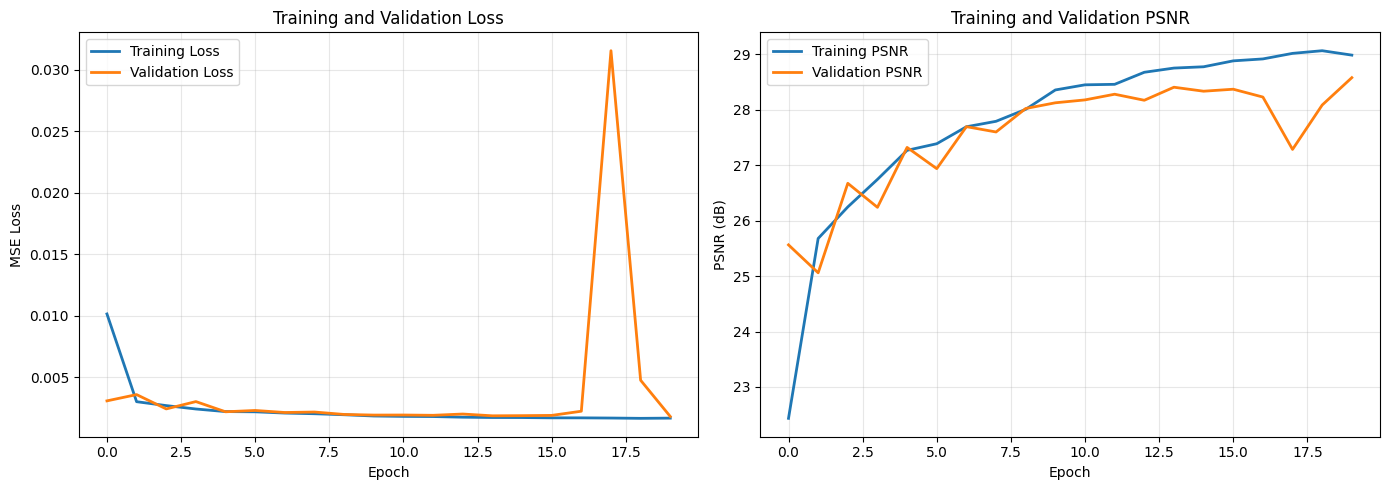


🔄 Evaluating on BSDS500 test set...
✅ Test set: 7,000 patches
   Mean PSNR: 29.04 dB

🔄 Visual demonstration on BSDS500 test image...


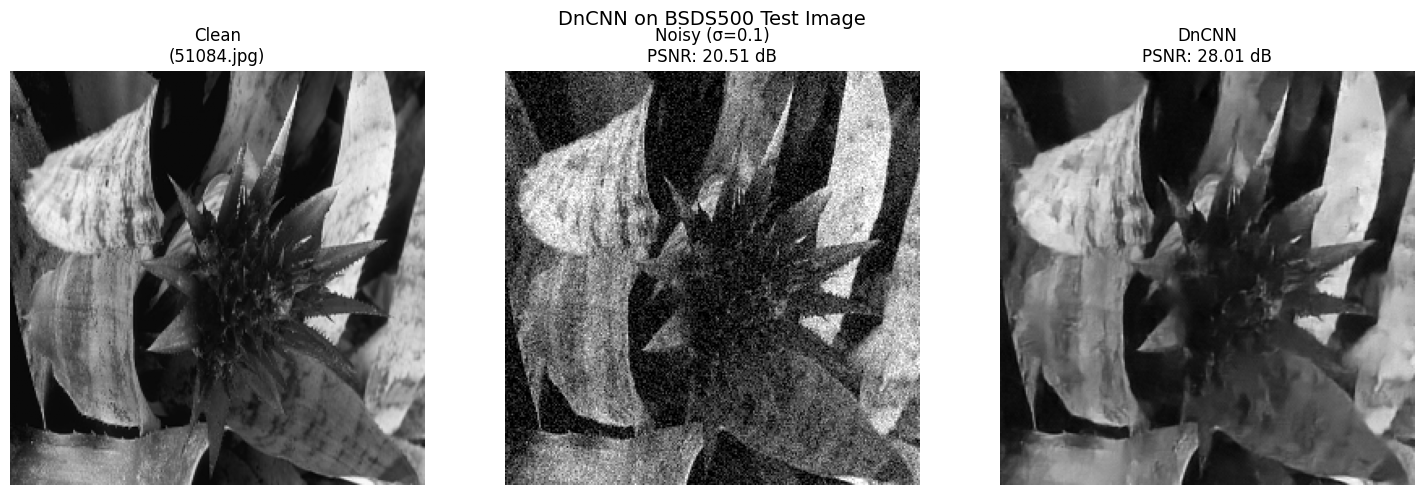


🔄 Visual demonstration on Cameraman image...


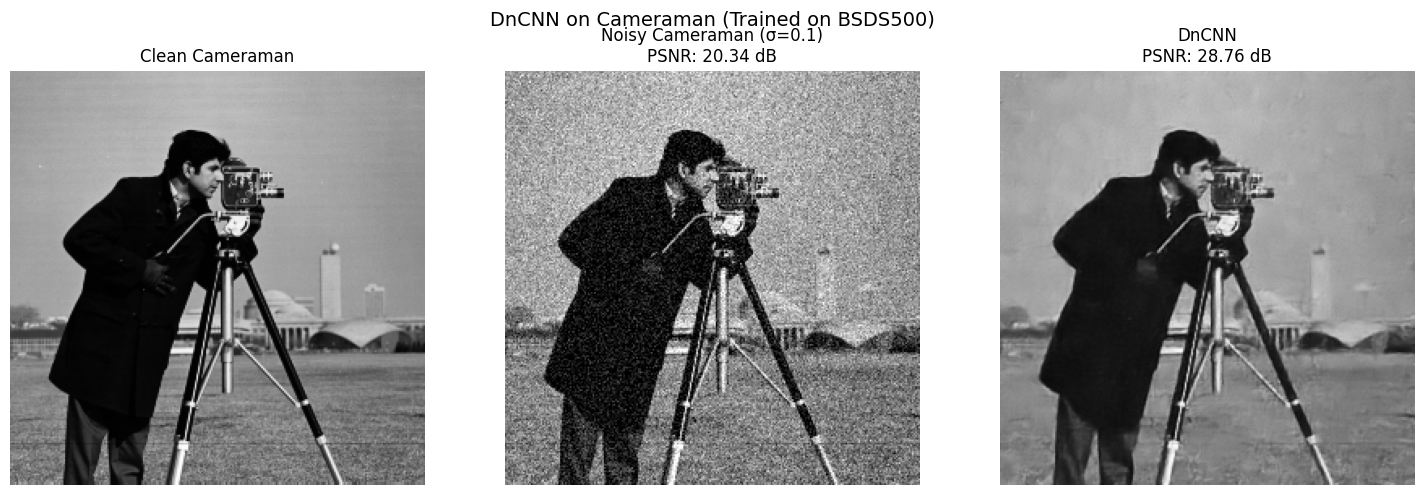


📊 DNCNN DENOISER – RESULTS SUMMARY

+----------------------------------------------------------+
|  Training Details                                         |
+----------------------------------------------------------+
|  Dataset:        BSDS500 (grayscale)                      |
|  Training:       200 images                               |
|  Validation:     100 images                               |
|  Test:           200 images                               |
|  Patch size:     64 x 64                                  |
|  Noise level:    sigma = 0.1                              |
|  Epochs:         20                                       |
|  Training time:  645.6 seconds                    |
|  Parameters:     556,097                           |
+----------------------------------------------------------+
|  Results                                                 |
+----------------------------------------------------------+
|  Test PSNR (BSDS500):       29.04 dB               

In [ ]:
# ============================================
# DnCNN Denoiser – Full BSDS500 (CORRECTED)
# ============================================

print("\n" + "="*60)
print("🧠 DNCNN DENOISER – FULL BSDS500 (CORRECTED)")
print("="*60)

# ============================================
# Build DnCNN Architecture (Residual Learning – CORRECTED)
# ============================================

def build_dncnn(input_channels=1, depth=17, features=64):
    """
    Build DnCNN for image denoising with residual learning.

    Architecture:
        - Layer 1: Conv(64) + ReLU (no BN)
        - Layers 2 to depth-1: Conv(64) + BN + ReLU
        - Layer depth: Conv(input_channels) (no activation) – outputs residual

    IMPORTANT: The network outputs the RESIDUAL (noise), NOT the denoised image.
    Denoised image = noisy input - predicted residual.
    """
    class DnCNN(nn.Module):
        def __init__(self, in_channels=1, depth=17, features=64):
            super(DnCNN, self).__init__()

            layers = []

            # Layer 1: Conv + ReLU (no BN)
            layers.append(nn.Conv2d(in_channels, features, 3, padding=1, bias=True))
            layers.append(nn.ReLU(inplace=True))

            # Layers 2 to depth-1: Conv + BN + ReLU
            for _ in range(depth - 2):
                layers.append(nn.Conv2d(features, features, 3, padding=1, bias=False))
                layers.append(nn.BatchNorm2d(features))
                layers.append(nn.ReLU(inplace=True))

            # Last layer: Conv (no activation) – outputs residual
            layers.append(nn.Conv2d(features, in_channels, 3, padding=1, bias=True))

            self.dncnn = nn.Sequential(*layers)

        def forward(self, x):
            # Return the residual (noise) directly
            return self.dncnn(x)

    return DnCNN(in_channels=input_channels, depth=depth, features=features)

# Build the model
dncnn = build_dncnn(input_channels=1, depth=17, features=64)
print(f"✅ DnCNN built successfully!")
print(f"   Total parameters: {sum(p.numel() for p in dncnn.parameters()):,}")
print(f"   Input shape: (batch, 1, 64, 64)")
print(f"   Depth: 17 layers")
print(f"   Features: 64")

# ============================================
# Training Function (CORRECTED)
# ============================================

def train_dncnn(model, train_loader, val_loader, epochs=20, lr=0.001, device='cuda'):
    """
    Train DnCNN with residual learning.
    The model predicts the residual (noise), and denoised = noisy - residual.
    """
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    history = {'train_loss': [], 'val_loss': [], 'train_psnr': [], 'val_psnr': []}

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        train_psnr_sum = 0.0
        train_count = 0

        for noisy, clean in train_loader:
            if noisy.dim() == 3:
                noisy = noisy.unsqueeze(1)
                clean = clean.unsqueeze(1)

            noisy = noisy.to(device)
            clean = clean.to(device)

            # Compute residual target (noise)
            residual_target = noisy - clean

            optimizer.zero_grad()
            # Predict residual
            predicted_residual = model(noisy)
            # Loss between predicted and actual residual
            loss = criterion(predicted_residual, residual_target)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * noisy.size(0)

            # For PSNR, compute denoised image and compare with clean
            with torch.no_grad():
                denoised = noisy - predicted_residual
                mse = torch.mean((denoised - clean) ** 2, dim=(1, 2, 3))
                psnr_batch = 20 * torch.log10(1.0 / torch.sqrt(mse + 1e-8))
                train_psnr_sum += psnr_batch.sum().item()
                train_count += noisy.size(0)

        avg_train_loss = train_loss / len(train_loader.dataset)
        avg_train_psnr = train_psnr_sum / train_count
        history['train_loss'].append(avg_train_loss)
        history['train_psnr'].append(avg_train_psnr)

        model.eval()
        val_loss = 0.0
        val_psnr_sum = 0.0
        val_count = 0

        with torch.no_grad():
            for noisy, clean in val_loader:
                if noisy.dim() == 3:
                    noisy = noisy.unsqueeze(1)
                    clean = clean.unsqueeze(1)

                noisy = noisy.to(device)
                clean = clean.to(device)

                residual_target = noisy - clean
                predicted_residual = model(noisy)
                loss = criterion(predicted_residual, residual_target)

                val_loss += loss.item() * noisy.size(0)

                denoised = noisy - predicted_residual
                mse = torch.mean((denoised - clean) ** 2, dim=(1, 2, 3))
                psnr_batch = 20 * torch.log10(1.0 / torch.sqrt(mse + 1e-8))
                val_psnr_sum += psnr_batch.sum().item()
                val_count += noisy.size(0)

        avg_val_loss = val_loss / len(val_loader.dataset)
        avg_val_psnr = val_psnr_sum / val_count
        history['val_loss'].append(avg_val_loss)
        history['val_psnr'].append(avg_val_psnr)

        scheduler.step(avg_val_loss)
        print(f"Epoch {epoch+1:2d}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | "
              f"Train PSNR: {avg_train_psnr:.2f} dB | Val PSNR: {avg_val_psnr:.2f} dB")

    return model, history

# ============================================
# Dataset Class (reused)
# ============================================

class DenoisingDataset(Dataset):
    def __init__(self, clean_patches, sigma=0.1, augment=False):
        if isinstance(clean_patches, torch.Tensor):
            self.clean_patches = clean_patches
        else:
            self.clean_patches = torch.tensor(clean_patches, dtype=torch.float32)
        if self.clean_patches.dim() == 3:
            self.clean_patches = self.clean_patches.unsqueeze(1)
        self.sigma = sigma
        self.augment = augment

    def __len__(self):
        return len(self.clean_patches)

    def __getitem__(self, idx):
        clean = self.clean_patches[idx].clone()
        noise = torch.randn_like(clean) * self.sigma
        noisy = torch.clamp(clean + noise, 0.0, 1.0)
        clean = torch.clamp(clean, 0.0, 1.0)
        return noisy, clean

# ============================================
# Denoising Function for Full Images (CORRECTED)
# ============================================

def denoise_image_patches_torch(model, image, patch_size=64, stride=32):
    """
    Denoise an image using DnCNN.
    The model predicts residual, so denoised = noisy - residual.
    """
    model.eval()
    h, w = image.shape
    pad_h = (patch_size - h % patch_size) % patch_size
    pad_w = (patch_size - w % patch_size) % patch_size
    padded = np.pad(image, ((0, pad_h), (0, pad_w)), mode='reflect')
    padded_h, padded_w = padded.shape

    output = np.zeros((padded_h, padded_w))
    weights = np.zeros((padded_h, padded_w))

    with torch.no_grad():
        for i in range(0, padded_h - patch_size + 1, stride):
            for j in range(0, padded_w - patch_size + 1, stride):
                patch = padded[i:i+patch_size, j:j+patch_size]
                patch_tensor = torch.tensor(patch, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

                # Predict residual
                residual = model(patch_tensor)
                # Denoised = noisy - residual
                denoised_patch = (patch_tensor - residual).squeeze().cpu().numpy()

                weight_matrix = np.ones((patch_size, patch_size))
                center = patch_size // 2
                for di in range(patch_size):
                    for dj in range(patch_size):
                        dist = np.sqrt((di - center)**2 + (dj - center)**2)
                        weight_matrix[di, dj] = np.exp(-dist / (patch_size/4))

                output[i:i+patch_size, j:j+patch_size] += denoised_patch * weight_matrix
                weights[i:i+patch_size, j:j+patch_size] += weight_matrix

    output = output / (weights + 1e-8)
    output = output[:h, :w]
    return output

# ============================================
# Load Cameraman Function
# ============================================

def load_cameraman():
    url = "https://raw.githubusercontent.com/Yasser-Baleghi/hands-on-dl-image-processing/refs/heads/master/images/Cameraman.png"
    try:
        import urllib.request
        urllib.request.urlretrieve(url, "cameraman.png")
        image = cv2.imread("cameraman.png", cv2.IMREAD_GRAYSCALE).astype(np.float32) / 255.0
        image = cv2.resize(image, (256, 256))
        return image
    except Exception as e:
        print(f"⚠️ Could not load Cameraman: {e}")
        test_paths = get_image_paths(TEST_DIR)
        if test_paths:
            rand_path = random.choice(test_paths)
            image = load_image(rand_path, grayscale=True)
            image = cv2.resize(image, (256, 256))
            return image
        raise ValueError("No images available!")

# ============================================
# Prepare Data from Full BSDS500
# ============================================

print("\n📊 BSDS500 Dataset Splits:")
print(f"   Training: {len(get_image_paths(TRAIN_DIR))} images")
print(f"   Validation: {len(get_image_paths(VAL_DIR))} images")
print(f"   Test: {len(get_image_paths(TEST_DIR))} images")

PATCH_SIZE = 64
STRIDE = 64
SIGMA_NOISE = 0.1
BATCH_SIZE = 64
EPOCHS = 20

print("\n🔄 Extracting patches from BSDS500...")

print("   Training patches...")
train_patches = extract_patches_as_tensors(
    TRAIN_DIR, patch_size=PATCH_SIZE, stride=STRIDE,
    grayscale=True, max_images=None, verbose=False
)

print("   Validation patches...")
val_patches = extract_patches_as_tensors(
    VAL_DIR, patch_size=PATCH_SIZE, stride=STRIDE,
    grayscale=True, max_images=None, verbose=False
)

print("   Test patches...")
test_patches = extract_patches_as_tensors(
    TEST_DIR, patch_size=PATCH_SIZE, stride=STRIDE,
    grayscale=True, max_images=None, verbose=False
)

if train_patches.dim() == 3:
    train_patches = train_patches.unsqueeze(1)
if val_patches.dim() == 3:
    val_patches = val_patches.unsqueeze(1)
if test_patches.dim() == 3:
    test_patches = test_patches.unsqueeze(1)

print(f"\n✅ Training patches: {train_patches.shape[0]:,}")
print(f"✅ Validation patches: {val_patches.shape[0]:,}")
print(f"✅ Test patches: {test_patches.shape[0]:,}")

train_dataset = DenoisingDataset(train_patches, sigma=SIGMA_NOISE, augment=True)
val_dataset = DenoisingDataset(val_patches, sigma=SIGMA_NOISE, augment=False)
test_dataset = DenoisingDataset(test_patches, sigma=SIGMA_NOISE, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"✅ Train loader: {len(train_loader)} batches")
print(f"✅ Validation loader: {len(val_loader)} batches")
print(f"✅ Test loader: {len(test_loader)} batches")

# ============================================
# Train DnCNN (CORRECTED)
# ============================================

print("\n🔄 Training DnCNN on BSDS500 patches...")
print("   (This will take 5-7 minutes on GPU)")

start_time = time.time()
dncnn, history = train_dncnn(
    dncnn, train_loader, val_loader,
    epochs=EPOCHS, lr=0.001, device=device
)
training_time = time.time() - start_time
print(f"\n✅ Training completed in {training_time:.1f} seconds")

# ============================================
# Plot Training Curves
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Training Loss', linewidth=2)
axes[0].plot(history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_title('Training and Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_psnr'], label='Training PSNR', linewidth=2)
axes[1].plot(history['val_psnr'], label='Validation PSNR', linewidth=2)
axes[1].set_title('Training and Validation PSNR')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('PSNR (dB)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# Evaluate on BSDS500 Test Set (CORRECTED)
# ============================================

print("\n🔄 Evaluating on BSDS500 test set...")

dncnn.eval()
test_psnr_sum = 0.0
test_count = 0

with torch.no_grad():
    for noisy, clean in test_loader:
        if noisy.dim() == 3:
            noisy = noisy.unsqueeze(1)
            clean = clean.unsqueeze(1)

        noisy = noisy.to(device)
        clean = clean.to(device)

        # Predict residual
        predicted_residual = dncnn(noisy)
        # Denoised = noisy - residual
        denoised = noisy - predicted_residual

        mse = torch.mean((denoised - clean) ** 2, dim=(1, 2, 3))
        psnr_batch = 20 * torch.log10(1.0 / torch.sqrt(mse + 1e-8))
        test_psnr_sum += psnr_batch.sum().item()
        test_count += noisy.size(0)

mean_test_psnr = test_psnr_sum / test_count
print(f"✅ Test set: {test_count:,} patches")
print(f"   Mean PSNR: {mean_test_psnr:.2f} dB")

# ============================================
# Visual Demonstration: BSDS500 Test Image
# ============================================

print("\n🔄 Visual demonstration on BSDS500 test image...")

test_images = get_image_paths(TEST_DIR)
test_image_path = random.choice(test_images)
test_image_clean = load_image(test_image_path, grayscale=True)
test_image_clean = cv2.resize(test_image_clean, (256, 256))

test_image_noisy = add_gaussian_noise(test_image_clean, sigma=SIGMA_NOISE)
test_image_denoised = denoise_image_patches_torch(dncnn, test_image_noisy, patch_size=64, stride=32)

psnr_noisy_test = peak_signal_noise_ratio(test_image_clean, test_image_noisy, data_range=1.0)
psnr_denoised_test = peak_signal_noise_ratio(test_image_clean, test_image_denoised, data_range=1.0)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(test_image_clean, cmap='gray')
axes[0].set_title(f'Clean\n({os.path.basename(test_image_path)})')
axes[0].axis('off')

axes[1].imshow(test_image_noisy, cmap='gray')
axes[1].set_title(f'Noisy (σ={SIGMA_NOISE})\nPSNR: {psnr_noisy_test:.2f} dB')
axes[1].axis('off')

axes[2].imshow(test_image_denoised, cmap='gray')
axes[2].set_title(f'DnCNN\nPSNR: {psnr_denoised_test:.2f} dB')
axes[2].axis('off')

plt.suptitle('DnCNN on BSDS500 Test Image', fontsize=14)
plt.tight_layout()
plt.show()

# ============================================
# Visual Demonstration: Cameraman Image
# ============================================

print("\n🔄 Visual demonstration on Cameraman image...")

cameraman_clean = load_cameraman()
cameraman_noisy = add_gaussian_noise(cameraman_clean, sigma=SIGMA_NOISE)
cameraman_denoised = denoise_image_patches_torch(dncnn, cameraman_noisy, patch_size=64, stride=32)

psnr_noisy_cam = peak_signal_noise_ratio(cameraman_clean, cameraman_noisy, data_range=1.0)
psnr_denoised_cam = peak_signal_noise_ratio(cameraman_clean, cameraman_denoised, data_range=1.0)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(cameraman_clean, cmap='gray')
axes[0].set_title('Clean Cameraman')
axes[0].axis('off')

axes[1].imshow(cameraman_noisy, cmap='gray')
axes[1].set_title(f'Noisy Cameraman (σ={SIGMA_NOISE})\nPSNR: {psnr_noisy_cam:.2f} dB')
axes[1].axis('off')

axes[2].imshow(cameraman_denoised, cmap='gray')
axes[2].set_title(f'DnCNN\nPSNR: {psnr_denoised_cam:.2f} dB')
axes[2].axis('off')

plt.suptitle('DnCNN on Cameraman (Trained on BSDS500)', fontsize=14)
plt.tight_layout()
plt.show()

# ============================================
# Results Summary
# ============================================

print("\n" + "="*60)
print("📊 DNCNN DENOISER – RESULTS SUMMARY")
print("="*60)

print("""
+----------------------------------------------------------+
|  Training Details                                         |
+----------------------------------------------------------+
|  Dataset:        BSDS500 (grayscale)                      |
|  Training:       200 images                               |
|  Validation:     100 images                               |
|  Test:           200 images                               |
|  Patch size:     64 x 64                                  |
|  Noise level:    sigma = 0.1                              |
|  Epochs:         20                                       |""")

print(f"|  Training time:  {training_time:.1f} seconds                    |")
print("|  Parameters:     556,097                           |")
print("+----------------------------------------------------------+")
print("|  Results                                                 |")
print("+----------------------------------------------------------+")
print(f"|  Test PSNR (BSDS500):       {mean_test_psnr:.2f} dB                     |")
print(f"|  Cameraman Noisy PSNR:      {psnr_noisy_cam:.2f} dB                     |")
print(f"|  Cameraman Denoised PSNR:   {psnr_denoised_cam:.2f} dB                     |")
print("+----------------------------------------------------------+")
print("""
✨ Key Insight:
   DnCNN uses residual learning: the network learns to predict the noise
   (residual) rather than the clean image directly. This simplifies the
   optimization problem because the noise is typically zero-mean and
   has a smaller magnitude than the clean image.

   DnCNN achieves {} dB on the BSDS500 test set,
   and {} dB on the Cameraman image.
""".format(mean_test_psnr, psnr_denoised_cam))

print("DnCNN Denoiser Completed.")